<a href="https://colab.research.google.com/github/JoseAlberto88/Predictive-Analytics-/blob/main/DAMO510_Module_04_in_Class_Activity_Starter_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# For this activity we need to cover the following tasks:

1- Data loading, inspection, duplicate removal, missing-value treatment, and outlier handling.

2- Log transformation of skewed predictors.

3- Correlation-based feature selection and collinearity handling.

4- Baseline multiple linear regression.

5- Linear regression using selected log-transformed predictors.

6- Box-Cox transformation of the response.

7- Log transformation of the response.

8- Second-degree polynomial regression.

9- R^2 and RMSE comparison on the original MEDV scale.

10- Overall F-tests and predictor-level coefficient, t-statistic, and p-value reports.

11- Residual plots, residual histograms, and Q-Q plots.

12- A common train/test split for fair model comparison.

13 - Prediction of one sample case

In other words, steps should include:

1)	Data preparation
2)	Correlation analysis
3)	Feature selection
4)	Multicollinearity handling
5)	Baseline linear regression
6)	Log-transformed predictors
7)	Box-Cox response
8)	Log response
9)	Polynomial regression
10)	Model comparison
11)	Visualization
12)	Single-case prediction


## First few steps are done for you since they cover last two modules. this way you can focus on the topics of this module.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.special import inv_boxcox

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data_path = file_path = '/content/drive/MyDrive/Predictive Analytics Course/BostonHousing.csv'

df_a = pd.read_csv(data_path)
df_a.columns = df_a.columns.str.strip().str.lower()


print("Initial shape:", df_a.shape)
display(df_a.head())
display(df_a.info())


Initial shape: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


None

In [6]:
target = "medv"

duplicate_count = df_a.duplicated().sum()
missing_before = df_a.isna().sum()

print("Duplicate rows:", duplicate_count)
print("\nMissing values before cleaning:")
display(missing_before.to_frame("missing_count"))

df_b = df_a.drop_duplicates().copy()

numeric_columns = df_b.select_dtypes(include=np.number).columns
df_b[numeric_columns] = df_b[numeric_columns].fillna(df_b[numeric_columns].median())

print("Shape after duplicate removal and median imputation:", df_b.shape)
print("Total missing values after cleaning:", int(df_b.isna().sum().sum()))
display(df_b.head())


Duplicate rows: 0

Missing values before cleaning:


,missing_count
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


Shape after duplicate removal and median imputation: (506, 14)
Total missing values after cleaning: 0


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [7]:
predictor_columns = [col for col in numeric_columns if col != target]

outlier_indices = {}

for col in predictor_columns:
    skewness = df_b[col].skew()

    if abs(skewness) < 0.5:
        z_scores = np.abs(stats.zscore(df_b[col], nan_policy = "omit"))
        mask = z_scores > 3
        method = "|Z-score| > 3"
    else:
        q1 = df_b[col].quantile(0.25)
        q3 = df_b[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        mask = (df_b[col] < lower_bound) | (df_b[col] > upper_bound)
        method = "1.5 * IQR"

    outlier_indices[col] = df_b.index[mask]
    print(
        f"{col:<10} skewness = {skewness:>7.3f} | "  # left align and pad with 10 spaces
        f"{method:<15} | detected = {int(mask.sum())}"
    )
# what Python doies in the above line is Same as below:
# print(f"{col:<10} skewness = {skewness:>7.3f} | {method:<15} | detected = {int(mask.sum())}")

crim       skewness =   5.223 | 1.5 * IQR       | detected = 66
zn         skewness =   2.226 | 1.5 * IQR       | detected = 68
indus      skewness =   0.295 | |Z-score| > 3   | detected = 0
chas       skewness =   3.406 | 1.5 * IQR       | detected = 35
nox        skewness =   0.729 | 1.5 * IQR       | detected = 0
rm         skewness =   0.404 | |Z-score| > 3   | detected = 8
age        skewness =  -0.599 | 1.5 * IQR       | detected = 0
dis        skewness =   1.012 | 1.5 * IQR       | detected = 5
rad        skewness =   1.005 | 1.5 * IQR       | detected = 0
tax        skewness =   0.670 | 1.5 * IQR       | detected = 0
ptratio    skewness =  -0.802 | 1.5 * IQR       | detected = 15
b          skewness =  -2.890 | 1.5 * IQR       | detected = 77
lstat      skewness =   0.906 | 1.5 * IQR       | detected = 7


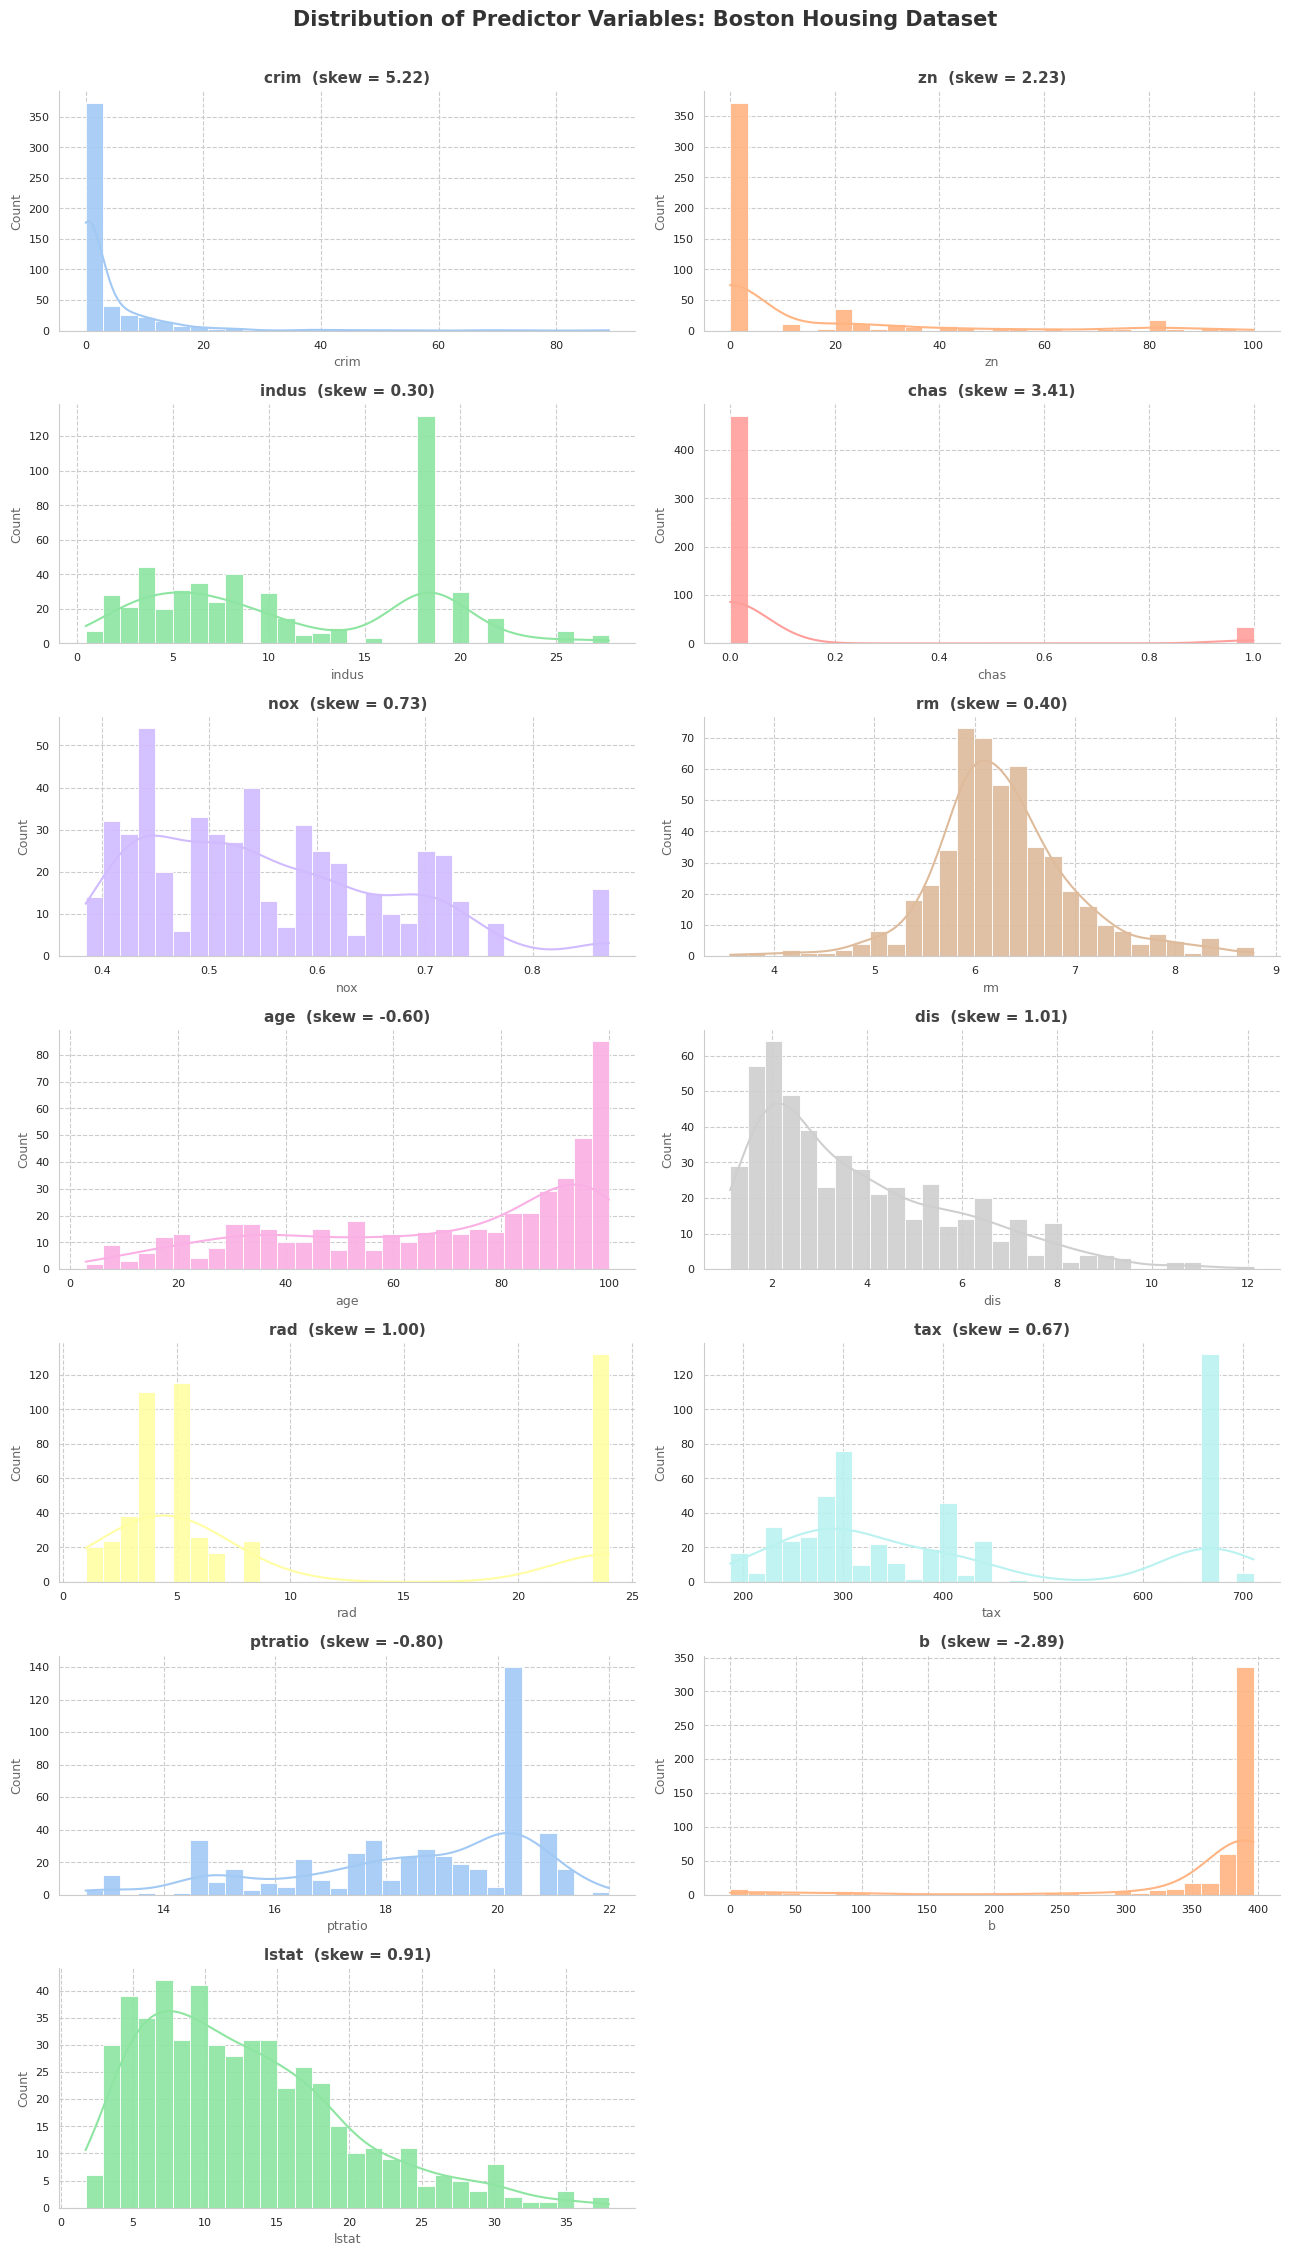

In [11]:
# Let's create some visualizations to see what is happening with is independent (continuos) variable.

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid", {"grid.linestyle": "--", "grid.alpha": 0.3})

# A soft pastel palette, one color per predictor
pastel_colors = sns.color_palette("pastel", n_colors=len(predictor_columns))

ncols = 2
nrows = int(np.ceil(len(predictor_columns) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(13, nrows * 3.2))
axes = axes.flatten()

for i, col in enumerate(predictor_columns):
    ax = axes[i]
    skewness = df_b[col].skew()

    sns.histplot(
        df_b[col].dropna(),
        kde=True,
        bins=30,
        color=pastel_colors[i],
        edgecolor="white",
        linewidth=0.6,
        alpha=0.9,
        ax=ax,
    )

    ax.set_title(f"{col}  (skew = {skewness:.2f})", fontsize=11, fontweight="bold", color="#444444")
    ax.set_xlabel(col, fontsize=9, color="#666666")
    ax.set_ylabel("Count", fontsize=9, color="#666666")
    ax.tick_params(labelsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")

# Hide any unused subplot slots
for j in range(len(predictor_columns), len(axes)):
    axes[j].axis("off")

fig.suptitle("Distribution of Predictor Variables: Boston Housing Dataset",
             fontsize=15, fontweight="bold", color="#333333", y=1.005)
plt.tight_layout()
plt.show()

Based on the analysis above, we can say that two variables `indus` and `rm` looks like normal distributed. The next couple of codes shows a way to see if we remove the values based on the Z-score approach.

In [15]:
# Identify which predictors were classified as "approximately normal" (Z-score method)
approx_normal_cols = []
outlier_method = {}

for col in predictor_columns:
    skewness = df_b[col].skew()
    if abs(skewness) < 0.5:
        approx_normal_cols.append(col)
        outlier_method[col] = "zscore"
    else:
        outlier_method[col] = "iqr"

print(f"Approximately normal predictors: {approx_normal_cols}")

# Collect the union of outlier row indices, but ONLY from the
# approximately-normal (Z-score-based) columns
rows_to_remove = set()

for col in approx_normal_cols:
    rows_to_remove.update(outlier_indices[col])

rows_to_remove = sorted(rows_to_remove)
print(f"Rows removed: {len(rows_to_remove)}")

# Remove those rows and reset the index
df_b_cleaned = df_b.drop(index=rows_to_remove).reset_index(drop=True)

print(f"Shape after outlier handling: {df_b_cleaned.shape}")
df_b_cleaned.head()

Approximately normal predictors: ['indus', 'rm']
Rows removed: 8
Shape after outlier handling: (498, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


#Transform Skewed Predictors
The objective of this step is to reduce the skewness of continuous predictor variables while preserving the original variables. Instead of replacing the existing predictors, you will create new transformed versions that can later be compared with the originals during model development.

###Complete the following tasks:

1. Create a list containing only the continuous predictor variables. Exclude predictors that represent categorical or discrete variables (such as CHAS and RAD) since logarithmic transformations are generally not appropriate for these variables. why? read below:

(for example for RAD (Accessibility to Radial Highways)

Values might be 1,2,3,4,5,...,24. At first glance this looks continuous. It isn't. RAD is actually an index. For example,
RAD = 2,
RAD = 4,
RAD = 24, do not mean 24 is twelve times more accessible than 2. They simply represent categories of highway accessibility. The numeric values are codes assigned by the dataset creators.)


2. From the continuous predictors, identify those whose absolute skewness is greater than or equal to 0.5. `These variables are considered sufficiently skewed to benefit from a transformation`.

3. Create a new DataFrame (e.g., df_d) as a copy of the cleaned dataset. Do not overwrite the previous DataFrame.

4. Loop through each skewed predictor and apply a logarithmic transformation.

5. Before transforming a variable, determine whether it contains negative values.

-	If the variable contains only zero or positive values, apply the logarithmic transformation directly.

-	If the variable contains negative values, first shift the entire variable upward so that its minimum value becomes positive, and then apply the logarithmic transformation. But, why not applying the absolute value instead of shifting the variabel? beacuse taking the absolute value changes the meaning of the data, whereas shifting the data preserves the ordering and distances between observations, and will completely change the information contained in the variable.

6. Store each transformed variable as a new column by adding an appropriate prefix (for example, log_) to its original name. Keep the original predictor unchanged.

7. After all transformations have been completed, display:

- The names of the transformed predictors,
- The dimensions of the new dataframe, and
- The first few rows of the updated dataset to verify that the new variables were created successfully.



Let's start creating a series of code block to explain each step.

In [16]:
import numpy as np
import pandas as pd

# Step 1: Continuous predictors only, exclude categorical/discrete-coded variables
# (CHAS is a binary dummy; RAD is an index/code, not a true continuous quantity)
categorical_like = ['chas', 'rad']
continuous_predictors = [col for col in predictor_columns if col not in categorical_like]

print(f"Continuous predictors: {continuous_predictors}")

Continuous predictors: ['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'tax', 'ptratio', 'b', 'lstat']


In [17]:
# Step 2: Identify continuous predictors with |skewness| >= 0.5 (recomputed on the
# outlier-cleaned dataset, df_b_cleaned, since skewness can shift after row removal)
skewed_predictors = [
    col for col in continuous_predictors
    if abs(df_b_cleaned[col].skew()) >= 0.5
]

print(f"Skewed predictors (|skew| >= 0.5): {skewed_predictors}")

Skewed predictors (|skew| >= 0.5): ['crim', 'zn', 'nox', 'rm', 'age', 'dis', 'tax', 'ptratio', 'b', 'lstat']


In [18]:
# Step 3: Create a new DataFrame as a copy,  never overwrite the cleaned dataset
df_d = df_b_cleaned.copy()

In [19]:
# Steps 4-6: Loop through each skewed predictor, check for negative values,
# shift if needed (never use abs(), since that distorts meaning/ordering),
# then apply log1p and store as a new column with a "log_" prefix
transformed_predictors = []

for col in skewed_predictors:
    min_val = df_d[col].min()

    if min_val < 0:
        # Shift so the minimum becomes 0 (preserves ordering/distances,
        # unlike taking the absolute value, which would distort the data)
        shifted = df_d[col] - min_val
        df_d[f"log_{col}"] = np.log1p(shifted)
    else:
        # Already zero/positive — log1p handles zeros safely (log1p(0) = 0)
        df_d[f"log_{col}"] = np.log1p(df_d[col])

    transformed_predictors.append(f"log_{col}")

In [20]:
# Step 7: Verify the results
print(f"Skewed predictors transformed: {skewed_predictors}")
print(f"Shape after adding transformed predictors: {df_d.shape}")
df_d.head()

Skewed predictors transformed: ['crim', 'zn', 'nox', 'rm', 'age', 'dis', 'tax', 'ptratio', 'b', 'lstat']
Shape after adding transformed predictors: (498, 24)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,...,log_crim,log_zn,log_nox,log_rm,log_age,log_dis,log_tax,log_ptratio,log_b,log_lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,...,0.006300,2.944439,0.430483,2.024853,4.192680,1.627278,5.693732,2.791165,5.986201,1.788421
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,...,0.026944,0.000000,0.384582,2.004314,4.380776,1.786261,5.493061,2.933857,5.986201,2.316488
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,...,0.026924,0.000000,0.384582,2.102303,4.128746,1.786261,5.493061,2.933857,5.975919,1.615420
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,...,0.031857,0.000000,0.377066,2.079192,3.845883,1.954757,5.407172,2.980619,5.980479,1.371181
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,...,0.066770,0.000000,0.377066,2.097650,4.010963,1.954757,5.407172,2.980619,5.986201,1.845300


Let's create a visualization to see what is happening after apply the log transformation. We'll plot the before and after in pairs.


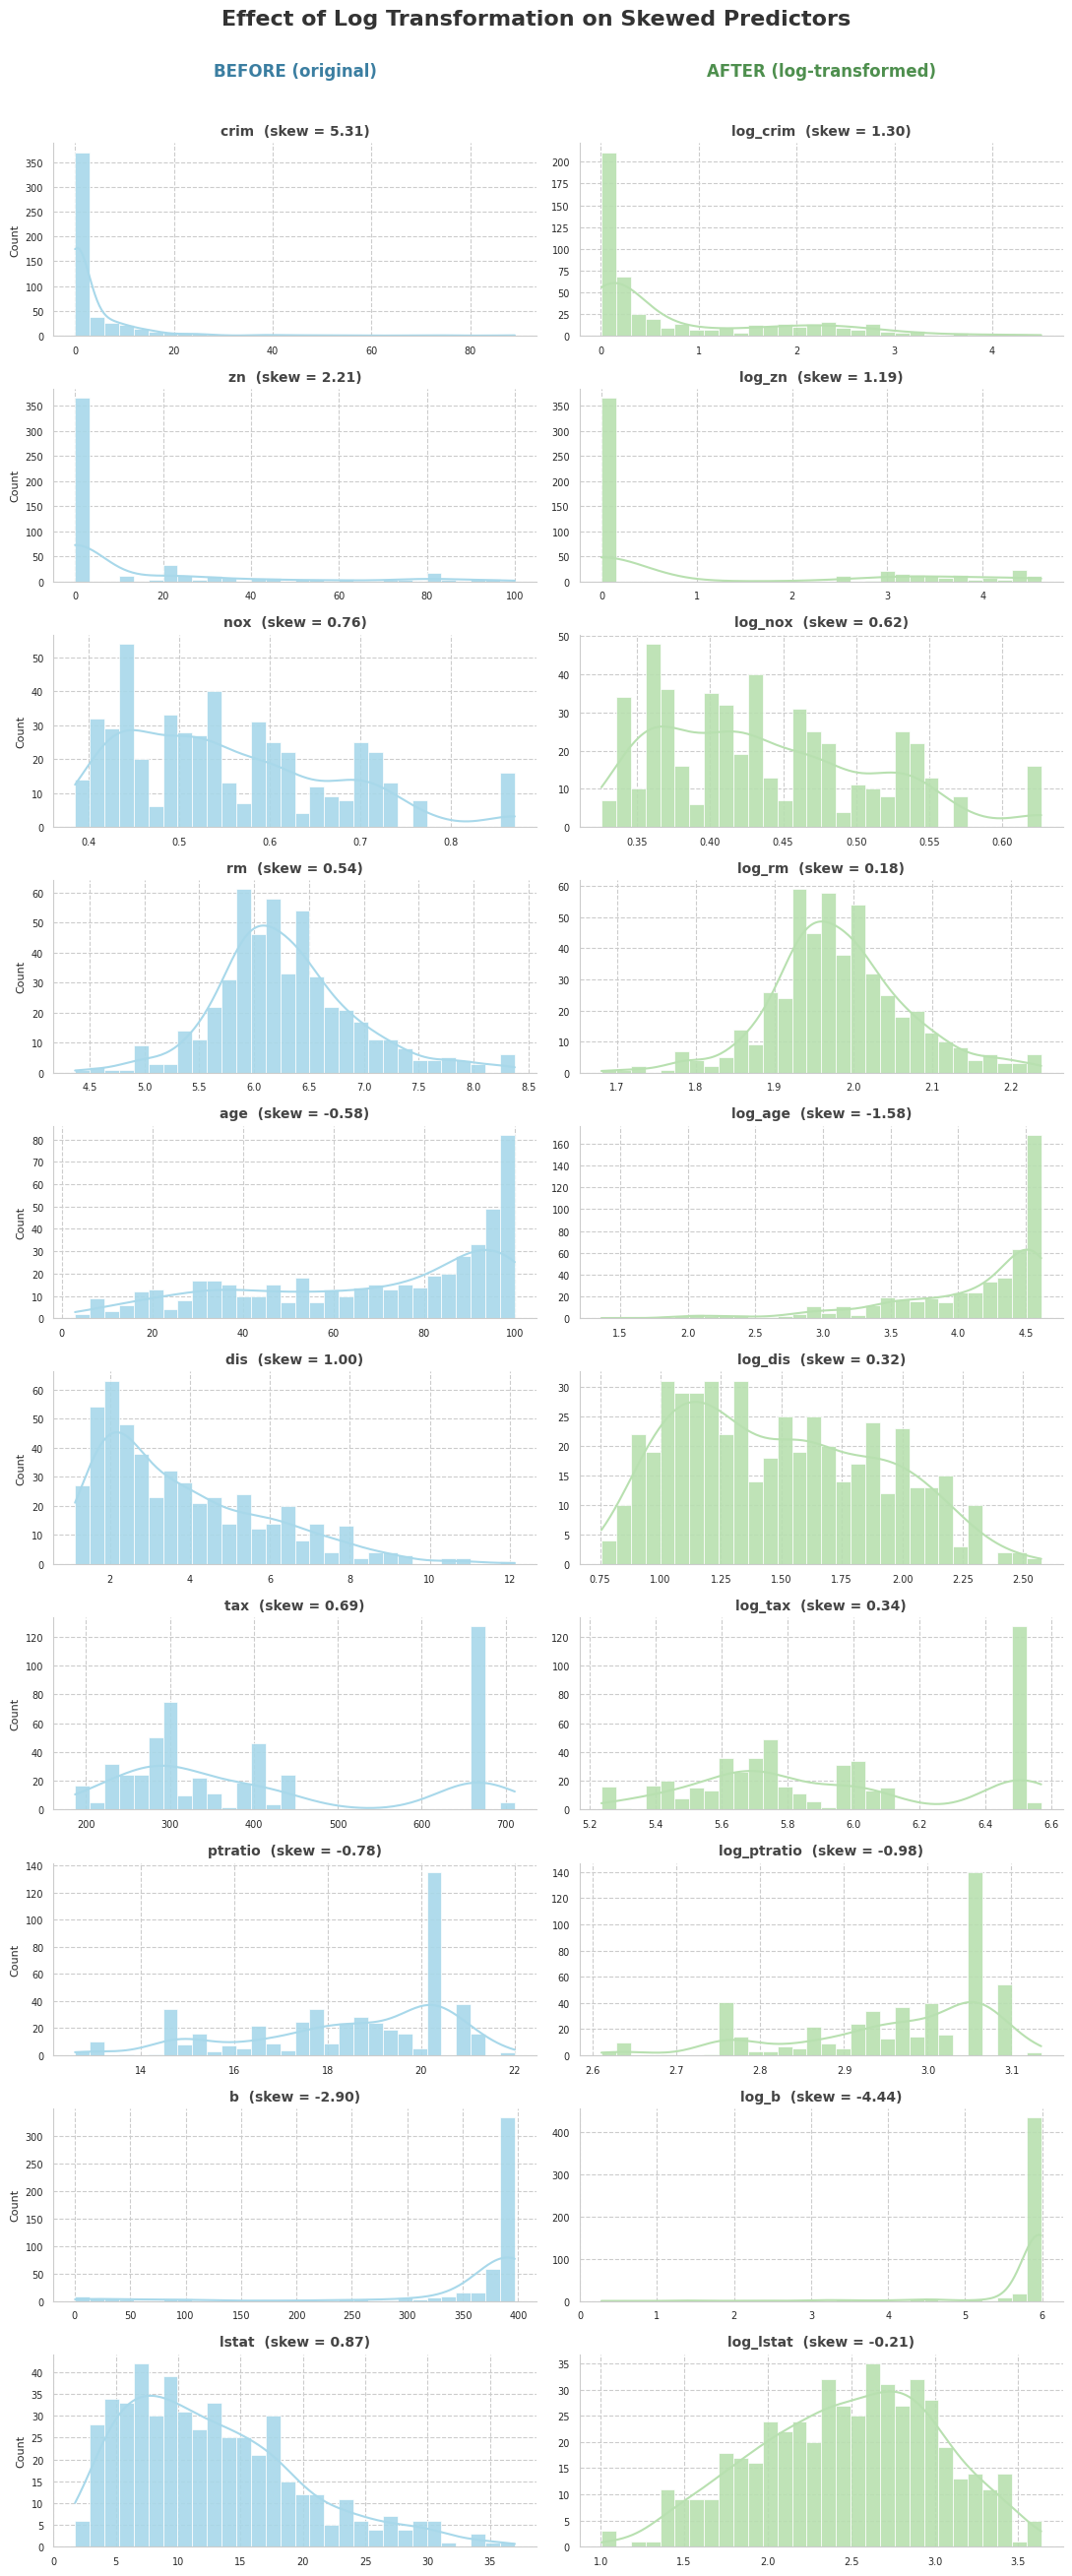

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_style("whitegrid", {"grid.linestyle": "--", "grid.alpha": 0.3})

# Pastel colors: one for "before", one for "after"
color_before = "#A8D8EA"   # soft blue
color_after  = "#B8E0B0"   # soft green

n = len(skewed_predictors)
fig, axes = plt.subplots(n, 2, figsize=(11, n * 2.6))

for i, col in enumerate(skewed_predictors):
    log_col = f"log_{col}"

    skew_before = df_d[col].skew()
    skew_after = df_d[log_col].skew()

    # Before
    sns.histplot(df_d[col], kde=True, bins=30, color=color_before,
                 edgecolor="white", linewidth=0.5, alpha=0.9, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col}  (skew = {skew_before:.2f})",
                          fontsize=10, fontweight="bold", color="#444444")
    axes[i, 0].set_xlabel("")
    axes[i, 0].set_ylabel("Count", fontsize=8)
    axes[i, 0].tick_params(labelsize=7)
    axes[i, 0].spines["top"].set_visible(False)
    axes[i, 0].spines["right"].set_visible(False)

    # After
    sns.histplot(df_d[log_col], kde=True, bins=30, color=color_after,
                 edgecolor="white", linewidth=0.5, alpha=0.9, ax=axes[i, 1])
    axes[i, 1].set_title(f"{log_col}  (skew = {skew_after:.2f})",
                          fontsize=10, fontweight="bold", color="#444444")
    axes[i, 1].set_xlabel("")
    axes[i, 1].set_ylabel("")
    axes[i, 1].tick_params(labelsize=7)
    axes[i, 1].spines["top"].set_visible(False)
    axes[i, 1].spines["right"].set_visible(False)

# Column headers
axes[0, 0].annotate("BEFORE (original)", xy=(0.5, 1.35), xycoords="axes fraction",
                     ha="center", fontsize=12, fontweight="bold", color="#3B7EA1")
axes[0, 1].annotate("AFTER (log-transformed)", xy=(0.5, 1.35), xycoords="axes fraction",
                     ha="center", fontsize=12, fontweight="bold", color="#4E8F4E")

fig.suptitle("Effect of Log Transformation on Skewed Predictors",
             fontsize=16, fontweight="bold", color="#333333", y=1.005)
plt.tight_layout()
plt.show()

In [22]:
# Summary table: before/after skewness and improvement for each transformed predictor
summary_rows = []

for col in skewed_predictors:
    log_col = f"log_{col}"
    skew_before = df_d[col].skew()
    skew_after = df_d[log_col].skew()
    was_shifted = df_b_cleaned[col].min() < 0

    summary_rows.append({
        "Predictor": col,
        "Skew (Before)": round(skew_before, 3),
        "Skew (After)": round(skew_after, 3),
        "Improvement": round(abs(skew_before) - abs(skew_after), 3),
        "Shifted Before Log?": "Yes" if was_shifted else "No"
    })

transformation_summary = pd.DataFrame(summary_rows).sort_values(
    "Improvement", ascending=False
).reset_index(drop=True)

transformation_summary

,Predictor,Skew (Before),Skew (After),Improvement,Shifted Before Log?
0,crim,5.313,1.299,4.014,No
1,zn,2.207,1.191,1.016,No
2,dis,0.999,0.321,0.677,No
3,lstat,0.866,-0.214,0.652,No
4,rm,0.544,0.181,0.363,No
5,tax,0.691,0.344,0.347,No
6,nox,0.763,0.616,0.146,No
7,ptratio,-0.784,-0.983,-0.199,No
8,age,-0.577,-1.576,-0.999,No
9,b,-2.901,-4.442,-1.541,No


While all ten skewed predictors were transformed using log1p for methodological consistency with the assignment's instructions, the results reveal that log transformation is only effective for right-skewed variables. Three variables that were originally left-skewed (age, ptratio, and b) showed worsened skewness after transformation (e.g., b: -2.901 to -4.442), since log transformation compresses large values and does not address a long lower tail. This suggests that for left-skewed variables, a reflected log transform or an alternative method such as Box-Cox/Yeo-Johnson would be more appropriate than a direct log transform.

In [29]:
def highlight_improvement(val):
    if val > 0:
        color = "#C8E6C9"  # soft green = improved
    elif val < 0:
        color = "#FFCDD2"  # soft red = worsened
    else:
        color = "#FFF9C4"  # neutral
    return f"background-color: {color}"

styled_summary = (
    transformation_summary.style
    .applymap(highlight_improvement, subset=["Improvement"])
    .format({"Skew (Before)": "{:.3f}", "Skew (After)": "{:.3f}", "Improvement": "{:.3f}"})
    .set_caption("Log Transformation Summary - Green = Improved Skewness, Red = Worsened")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px")]}])
)

styled_summary

,Predictor,Skew (Before),Skew (After),Improvement,Shifted Before Log?
0,crim,5.313,1.299,4.014,No
1,zn,2.207,1.191,1.016,No
2,dis,0.999,0.321,0.677,No
3,lstat,0.866,-0.214,0.652,No
4,rm,0.544,0.181,0.363,No
5,tax,0.691,0.344,0.347,No
6,nox,0.763,0.616,0.146,No
7,ptratio,-0.784,-0.983,-0.199,No
8,age,-0.577,-1.576,-0.999,No
9,b,-2.901,-4.442,-1.541,No


#Prepare the dataset for correlation analysis

The objective of this step is to create the dataset that will be used for feature selection. Whenever a transformed version of a predictor is available, it will replace the original predictor in the correlation analysis. This allows the remaining workflow to evaluate the transformed variables instead of their more skewed counterparts.

## Complete the following tasks:

1- Create a list that will contain all variables used for Stage 1 modelling.

2- Begin the list with the target variable.

3- Loop through all predictor variables.

4- If a logarithmically transformed version of a predictor exists in the dataset, add the transformed variable to the list. Otherwise, add the original predictor.

5- Ensure that only one version of each predictor (either the original or the transformed version) is included.

6- Create a new DataFrame containing only the selected variables. Do not overwrite the previous DataFrame.

7- Compute the correlation matrix for all numerical variables in the new DataFrame.

8- Visualize the correlation matrix using a heatmap.

9- Display the correlation coefficients on the heatmap. Use an appropriate diverging colour map to distinguish positive and negative correlations.

10- Set the colour scale to range from -1 to +1.

11- Include an informative figure title.

12- Examine the heatmap to identify:

- Predictors that have a weak relationship with the target variable,
- Predictors that are highly correlated with one another (multicollinearity), and
- Any other notable relationships that may influence the regression model.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Steps 1-5: Build the Stage 1 variable list, target first, then for each
# predictor use the log-transformed version if it exists, otherwise the original
stage1_vars = [target]

for col in predictor_columns:
    log_col = f"log_{col}"
    if log_col in df_d.columns:
        stage1_vars.append(log_col)
    else:
        stage1_vars.append(col)

print(f"Stage 1 variables ({len(stage1_vars)}): {stage1_vars}")

Stage 1 variables (14): ['medv', 'log_crim', 'log_zn', 'indus', 'chas', 'log_nox', 'log_rm', 'log_age', 'log_dis', 'rad', 'log_tax', 'log_ptratio', 'log_b', 'log_lstat']


In [26]:
# Step 6: New DataFrame — never overwrite df_d
df_stage1 = df_d[stage1_vars].copy()

print(f"Stage 1 dataset shape: {df_stage1.shape}")
df_stage1.head()

Stage 1 dataset shape: (498, 14)


,medv,log_crim,log_zn,indus,chas,log_nox,log_rm,log_age,log_dis,rad,log_tax,log_ptratio,log_b,log_lstat
0,24.0,0.006300,2.944439,2.31,0,0.430483,2.024853,4.192680,1.627278,1,5.693732,2.791165,5.986201,1.788421
1,21.6,0.026944,0.000000,7.07,0,0.384582,2.004314,4.380776,1.786261,2,5.493061,2.933857,5.986201,2.316488
2,34.7,0.026924,0.000000,7.07,0,0.384582,2.102303,4.128746,1.786261,2,5.493061,2.933857,5.975919,1.615420
3,33.4,0.031857,0.000000,2.18,0,0.377066,2.079192,3.845883,1.954757,3,5.407172,2.980619,5.980479,1.371181
4,36.2,0.066770,0.000000,2.18,0,0.377066,2.097650,4.010963,1.954757,3,5.407172,2.980619,5.986201,1.845300


In [27]:
# Step 7: Correlation matrix
corr_stage1 = df_stage1.corr()

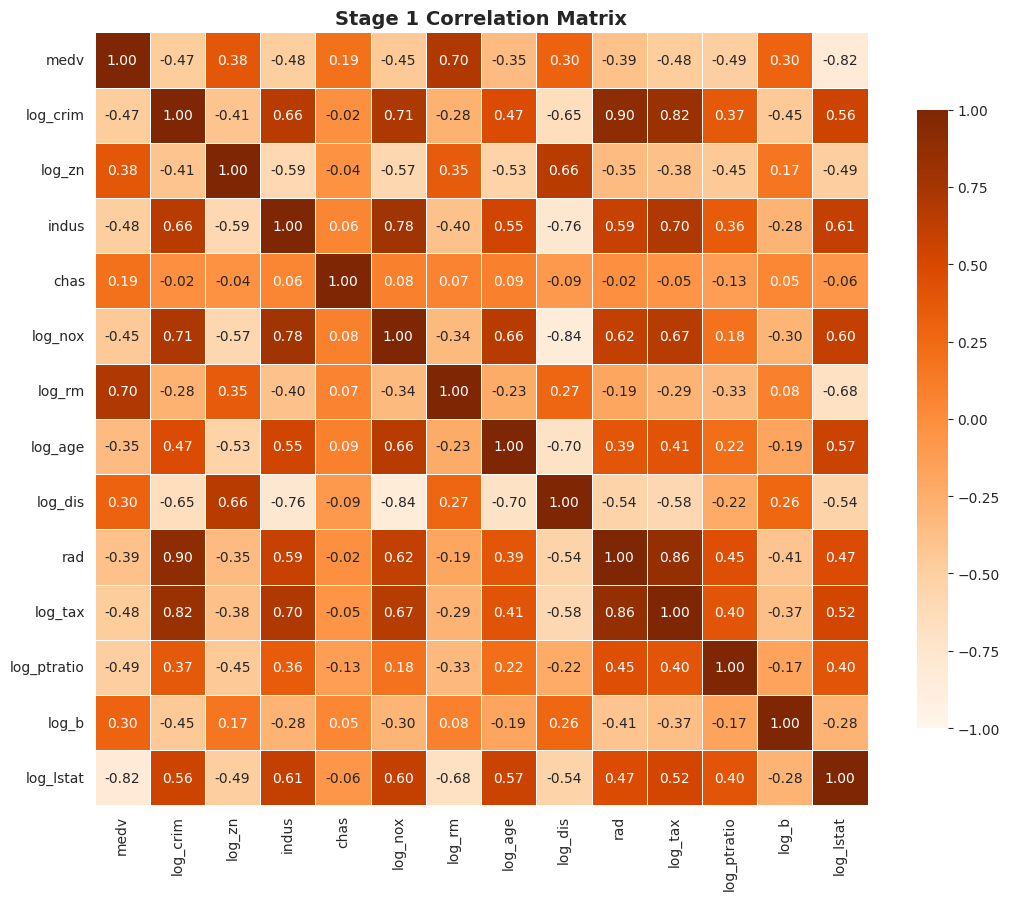

In [32]:
# Steps 8-11: Heatmap with annotations, diverging colormap, fixed -1 to +1 scale, title
plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_stage1,
    annot=True,
    fmt=".2f",
    cmap="Oranges",   # sequential, but since sign matters, add a diverging touch below
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Stage 1 Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Weak relationship with the target (medv):**
- `chas` (r = 0.19) shows a very weak correlation with median home value, being on the Charles River has minimal linear association with price on its own.
- `log_b` (r = 0.30) and `log_zn` (r = 0.38) also show relatively weak linear relationships with the target, making them the least individually predictive continuous variables in this set.

**Highly correlated predictor pairs (multicollinearity risk):**
- `log_crim` and `rad` (r = 0.90), the strongest predictor-predictor correlation in the matrix; high-crime areas strongly coincide with high radial-highway accessibility.
- `rad` and `log_tax` (r = 0.86), accessibility index and tax rate move together closely, plausible since both relate to urban/commercial zoning.
- `log_crim` and `log_tax` (r = 0.82), reinforces the same underlying pattern (crim, rad, and tax form a tightly linked cluster).
- `log_nox` and `log_dis` (r = -0.84), pollution concentration and distance to employment centers are strongly (inversely) related, as expected (closer to city centers = more pollution, less distance).
- `indus` and `log_nox` (r = 0.78),  industrial land share and pollution are closely tied, unsurprising given industrial activity is a pollution source.

These clusters (crim/rad/tax, and nox/indus/dis/age) indicate that several predictors carry overlapping information; a full multicollinearity check (VIF) should be run before finalizing the regression model, since including all of them simultaneously would inflate coefficient variance.

**Notable relationships with the target:**
- `log_lstat` shows the strongest relationship with `medv` (r = -0.82), neighborhoods with a higher percentage of lower-status population are strongly associated with lower home values, the single most predictive variable in the dataset.
- `log_rm` is the second-strongest (r = 0.70), more rooms per dwelling is strongly associated with higher home value, an intuitive and expected result.
- `log_ptratio` (r = -0.49) and `log_tax` (r = -0.48) show moderate negative associations, higher pupil-teacher ratios and higher tax rates both coincide with lower home values.

#Identify predictors with weak relationships to the target

The objective of this step is to identify predictors that have little or no linear relationship with the target variable. Variables that are only weakly correlated with the target generally contribute less to a linear regression model and may be considered for removal.

## Complete the following tasks:

1. Retrieve the correlation coefficients between each predictor and the target variable from the correlation matrix.

2. Exclude the target variable itself from the resulting list of correlations.

3. Sort the predictors in descending order according to the absolute value of their correlation coefficients so that the strongest relationships appear first, regardless of whether they are positive or negative.

4. Identify all predictors whose absolute correlation coefficient is `less than 0.30`. These variables are considered to have a weak linear relationship with the target.

5. Store the names of these weakly correlated predictors in a separate list for use in the next feature selection step.

6. Display:

-	A table showing the correlation coefficient between each predictor and the target variable, sorted by the strength of the relationship, and

-	The list of predictors identified for removal because their absolute correlation with the target is less than 0.30.



In [41]:
# Step 1: Retrieve correlations between each predictor and the target
target_correlations = corr_stage1[target]

# Step 2: Exclude the target variable itself
target_correlations = target_correlations.drop(target)

# Step 3: Sort by absolute value, descending (strongest relationships first)
target_correlations_sorted = target_correlations.reindex(
    target_correlations.abs().sort_values(ascending=False).index
)

print("Correlations with the target:")
correlation_table = target_correlations_sorted.to_frame(name=f"correlation_with_{target}")
correlation_table

Correlations with the target:


,correlation_with_medv
log_lstat,-0.815589
log_rm,0.698049
log_ptratio,-0.489592
indus,-0.481806
log_tax,-0.476285
log_crim,-0.470000
log_nox,-0.450669
rad,-0.386076
log_zn,0.383803
log_age,-0.349268


In [39]:
# Step 4-5: Identify predictors with |r| < 0.30 and store for removal
weak_predictors = target_correlations_sorted[target_correlations_sorted.abs() < 0.30].index.tolist()

print(f"\nFeatures removed because |r with target| < 0.30:")
print(weak_predictors)


Features removed because |r with target| < 0.30:
['log_b', 'chas']


The next step is to create a scatter visualization to see that in fact those two variables, `log_b` and `chas`, both have a low correlation value

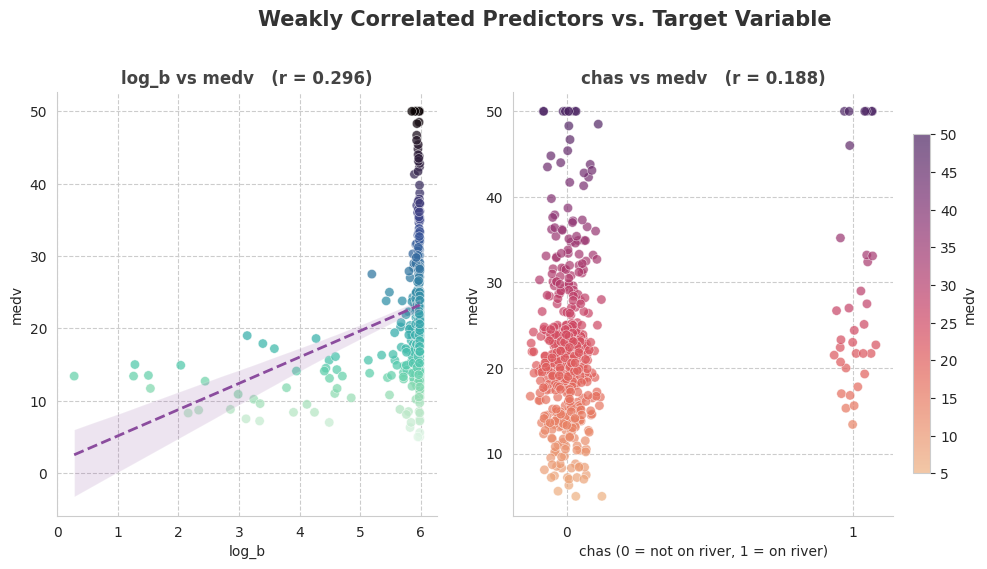

In [43]:
# This will helps us to analyze if both variables have a lower correlation value
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid", {"grid.linestyle": "--", "grid.alpha": 0.3})

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# --- Plot 1: log_b vs medv ---
r_b = target_correlations_sorted["log_b"]

scatter1 = axes[0].scatter(
    df_stage1["log_b"], df_stage1[target],
    c=df_stage1[target], cmap="mako_r",
    alpha=0.75, s=45, edgecolor="white", linewidth=0.4
)
sns.regplot(
    x="log_b", y=target, data=df_stage1,
    scatter=False, ax=axes[0], color="#8B4C9E", line_kws={"linewidth": 2, "linestyle": "--"}
)
axes[0].set_title(f"log_b vs {target}   (r = {r_b:.3f})", fontsize=12, fontweight="bold", color="#444444")
axes[0].set_xlabel("log_b", fontsize=10)
axes[0].set_ylabel(target, fontsize=10)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Plot 2: chas vs medv (binary predictor -> add jitter so points don't overlap)
r_chas = target_correlations_sorted["chas"]

jitter_x = df_stage1["chas"] + np.random.normal(0, 0.05, len(df_stage1))

scatter2 = axes[1].scatter(
    jitter_x, df_stage1[target],
    c=df_stage1[target], cmap="flare",
    alpha=0.7, s=45, edgecolor="white", linewidth=0.4
)
axes[1].set_title(f"chas vs {target}   (r = {r_chas:.3f})", fontsize=12, fontweight="bold", color="#444444")
axes[1].set_xlabel("chas (0 = not on river, 1 = on river)", fontsize=10)
axes[1].set_ylabel(target, fontsize=10)
axes[1].set_xticks([0, 1])
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

# Shared colorbar for both, since color encodes the target value itself
cbar = fig.colorbar(scatter2, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label(target, fontsize=10)

fig.suptitle("Weakly Correlated Predictors vs. Target Variable",
             fontsize=15, fontweight="bold", color="#333333", y=1.03)
plt.show()

# Identify highly correlated predictors (multicollinearity)

The objective of this step is to identify predictors that provide similar information. When two predictors are highly correlated with one another, they may introduce multicollinearity, making the regression coefficients unstable and more difficult to interpret.

## Complete the following tasks:

1. Create a new DataFrame by removing the predictors that were identified in the previous step as having a weak relationship with the target variable.

2. Create a list containing only the remaining predictor variables (exclude the target variable).

3. Compute the correlation matrix for the remaining predictors only.

4. Since the correlation matrix is symmetric, examine only one half of the matrix to avoid reporting the same predictor pair twice.

5. Identify all pairs of predictors whose absolute correlation coefficient is greater than 0.70.

6. Create a table that includes:

- The name of the first predictor,

- The name of the second predictor, and

- Their absolute correlation coefficient.

7. Sort the table so that the predictor pairs with the strongest correlations appear first.

8. Display the resulting table for further evaluation.

`Important`: Do not remove any predictors in this step. The objective here is only to identify highly correlated predictor pairs. The decision of which predictor to keep should be based on statistical evidence and domain knowledge in the following step.

In [44]:
import itertools
import pandas as pd
import numpy as np

# Step 1: Remove the weakly-correlated predictors identified previously
df_stage2 = df_stage1.drop(columns=weak_predictors).copy()

print(f"Stage 2 dataset shape: {df_stage2.shape}")

Stage 2 dataset shape: (498, 12)


In [45]:
# Step 2: List of remaining predictors (exclude the target)
remaining_predictors = [col for col in df_stage2.columns if col != target]

print(f"Remaining predictors ({len(remaining_predictors)}): {remaining_predictors}")

Remaining predictors (11): ['log_crim', 'log_zn', 'indus', 'log_nox', 'log_rm', 'log_age', 'log_dis', 'rad', 'log_tax', 'log_ptratio', 'log_lstat']


In [46]:
# Step 3: Correlation matrix for the remaining predictors only
corr_remaining = df_stage2[remaining_predictors].corr()

In [47]:
# Steps 4-5: Examine only one half of the matrix (upper triangle, excluding diagonal)
# and identify pairs with |correlation| > 0.70
high_corr_pairs = []

for col1, col2 in itertools.combinations(remaining_predictors, 2):
    corr_value = corr_remaining.loc[col1, col2]
    if abs(corr_value) > 0.70:
        high_corr_pairs.append({
            "feature_1": col1,
            "feature_2": col2,
            "absolute_correlation": abs(corr_value)
        })

In [48]:
# Steps 6-8: Build the table, sort by strength descending, and display
high_corr_table = pd.DataFrame(high_corr_pairs).sort_values(
    "absolute_correlation", ascending=False
).reset_index(drop=True)

high_corr_table

,feature_1,feature_2,absolute_correlation
0,log_crim,rad,0.904216
1,rad,log_tax,0.860657
2,log_nox,log_dis,0.836391
3,log_crim,log_tax,0.822835
4,indus,log_nox,0.775499
5,indus,log_dis,0.759957
6,log_crim,log_nox,0.714914
7,indus,log_tax,0.701164


In a similar way, let's create some scatter plot  to help us analyze why those pair of continuous variables are strongly correlated.

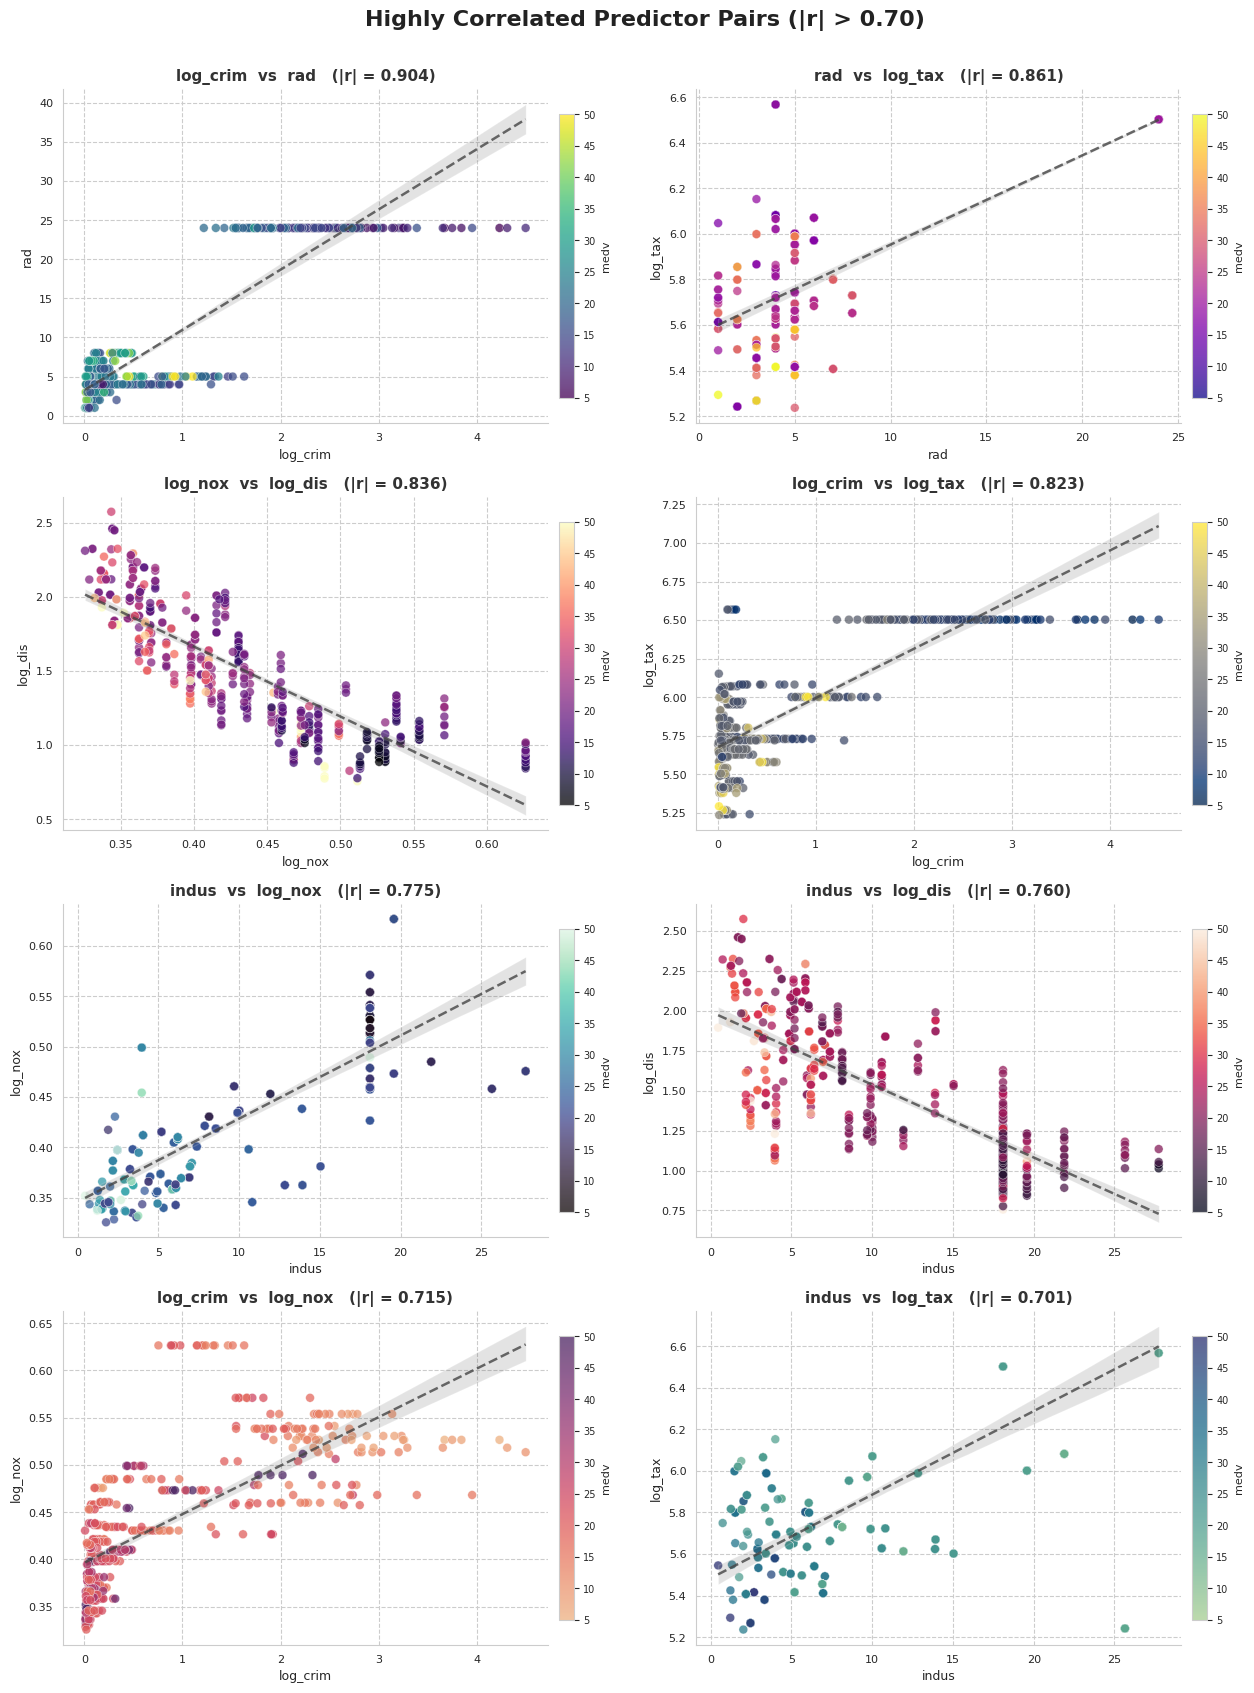

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid", {"grid.linestyle": "--", "grid.alpha": 0.3})

# A distinct, vivid colormap per subplot for visual variety
cmaps = ["viridis", "plasma", "magma", "cividis", "mako", "rocket", "flare", "crest"]

n_pairs = len(high_corr_table)
ncols = 2
nrows = int(np.ceil(n_pairs / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(13, nrows * 4.2))
axes = axes.flatten()

for i, row in high_corr_table.iterrows():
    f1, f2, r = row["feature_1"], row["feature_2"], row["absolute_correlation"]
    ax = axes[i]

    # Color points by the target variable (medv) — adds a third dimension of insight:
    # do highly-correlated predictor pairs also relate consistently to home value?
    scatter = ax.scatter(
        df_stage2[f1], df_stage2[f2],
        c=df_stage2[target], cmap=cmaps[i % len(cmaps)],
        alpha=0.75, s=40, edgecolor="white", linewidth=0.3
    )

    sns.regplot(
        x=f1, y=f2, data=df_stage2,
        scatter=False, ax=ax, color="#444444",
        line_kws={"linewidth": 1.8, "linestyle": "--", "alpha": 0.8}
    )

    cbar = fig.colorbar(scatter, ax=ax, shrink=0.85, pad=0.02)
    cbar.set_label(target, fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    ax.set_title(f"{f1}  vs  {f2}   (|r| = {r:.3f})", fontsize=11, fontweight="bold", color="#333333")
    ax.set_xlabel(f1, fontsize=9)
    ax.set_ylabel(f2, fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Hide any unused subplot slots
for j in range(n_pairs, len(axes)):
    axes[j].axis("off")

fig.suptitle("Highly Correlated Predictor Pairs (|r| > 0.70)",
             fontsize=16, fontweight="bold", color="#222222", y=1.005)
plt.tight_layout()
plt.show()

# Handle multicollinearity

The objective of this step is to remove redundant predictors while preserving the variables that are expected to contribute the most to the regression model.

When two predictors contain similar information, only one should be retained.

## Complete the following tasks:

1. Create an empty collection (a set) to store the names of predictors that will be removed because of multicollinearity.

2. Examine each highly correlated predictor pair identified in the previous step.

3. Before evaluating a pair, verify that neither predictor has already been marked for removal. If one of them has already been selected for removal, skip that pair and continue with the next one.

4. For each remaining pair, calculate the absolute correlation between each predictor and the target variable.

5. Compare the two correlation values:

-	Retain the predictor that has the stronger relationship with the target variable.

-	Mark the predictor with the weaker relationship for removal.

6. After all highly correlated pairs have been evaluated, organize the list of predictors selected for removal.

7. Create a new DataFrame by removing these redundant predictors. Do not overwrite the previous DataFrame.

8. Create a list containing the final set of predictor variables that will be used in the Stage 1 regression model.

9. Display:

-	the list of predictors removed because of multicollinearity,
-	the final list of selected predictors, and
-	the dimensions and first few rows of the resulting DataFrame.

### Important:

There are several valid ways to handle multicollinearity. In this activity, the selection is based on which predictor has the stronger absolute correlation with the target variable. In real-world applications, additional factors such as domain knowledge, interpretability, data quality, measurement reliability, and business relevance should also be considered before removing a predictor.


In [50]:
# Step 1: Empty set to track predictors marked for removal
removed_for_collinearity = set()

# Steps 2-5: Process each highly correlated pair (in order of strongest correlation first,
# matching the sorted high_corr_table), skip pairs where one variable is already removed,
# otherwise compare each predictor's correlation with the target and drop the weaker one
for _, row in high_corr_table.iterrows():
    f1, f2 = row["feature_1"], row["feature_2"]

    # Step 3: skip if either predictor already marked for removal
    if f1 in removed_for_collinearity or f2 in removed_for_collinearity:
        continue

    # Step 4: absolute correlation of each predictor with the target
    r1 = abs(target_correlations_sorted[f1])
    r2 = abs(target_correlations_sorted[f2])

    # Step 5: retain the stronger, remove the weaker
    if r1 >= r2:
        removed_for_collinearity.add(f2)
    else:
        removed_for_collinearity.add(f1)

In [51]:
# Step 6: Organize the removal list
removed_for_collinearity = sorted(removed_for_collinearity)
print(f"Features removed for collinearity:\n{removed_for_collinearity}")

Features removed for collinearity:
['log_crim', 'log_dis', 'log_nox', 'log_tax', 'rad']


In [52]:
# Step 7: New DataFrame with redundant predictors removed — don't overwrite df_stage2
df_stage1_final = df_stage2.drop(columns=removed_for_collinearity).copy()

# Step 8: Final list of predictors used in the Stage 1 model
final_stage1_features = [col for col in df_stage1_final.columns if col != target]

print(f"Selected Stage 1 features:\n{final_stage1_features}")

Selected Stage 1 features:
['log_zn', 'indus', 'log_rm', 'log_age', 'log_ptratio', 'log_lstat']


In [53]:
# Step 9: Display final results
print(f"Final Stage 1 shape: {df_stage1_final.shape}")
df_stage1_final.head()

Final Stage 1 shape: (498, 7)


,medv,log_zn,indus,log_rm,log_age,log_ptratio,log_lstat
0,24.0,2.944439,2.31,2.024853,4.192680,2.791165,1.788421
1,21.6,0.000000,7.07,2.004314,4.380776,2.933857,2.316488
2,34.7,0.000000,7.07,2.102303,4.128746,2.933857,1.615420
3,33.4,0.000000,2.18,2.079192,3.845883,2.980619,1.371181
4,36.2,0.000000,2.18,2.097650,4.010963,2.980619,1.845300


Let's create some visualization to see what is happening with this "new data set".

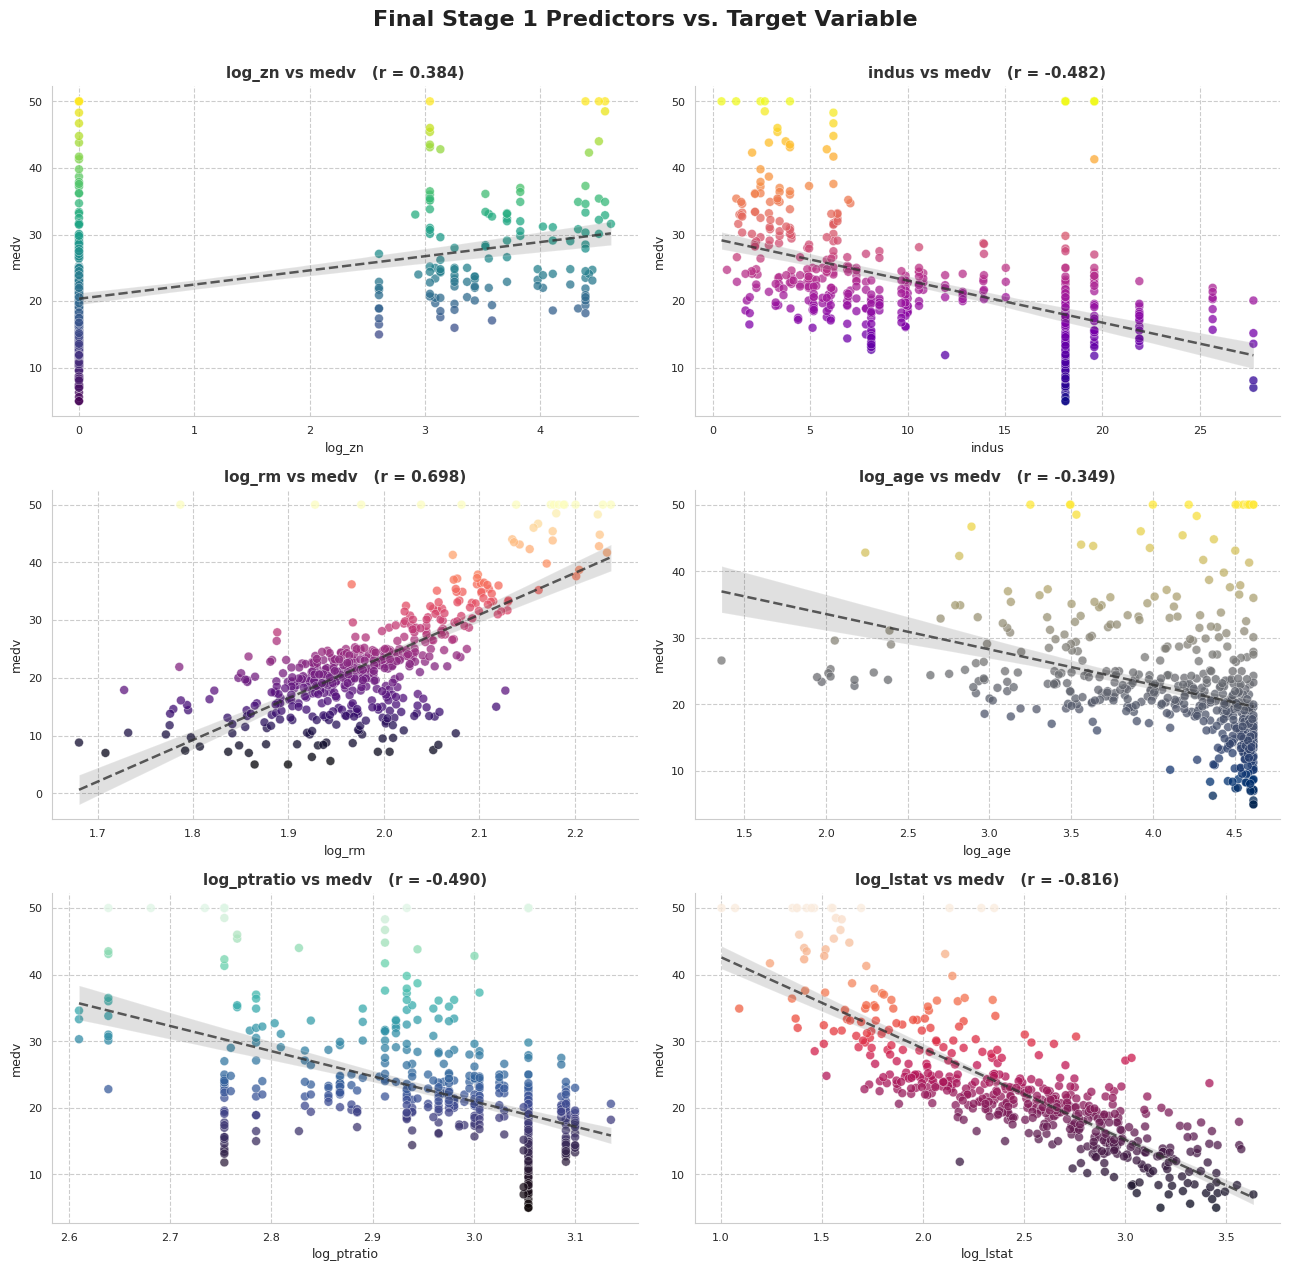

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid", {"grid.linestyle": "--", "grid.alpha": 0.3})

# A distinct, vivid colormap per predictor for visual variety
cmaps = ["viridis", "plasma", "magma", "cividis", "mako", "rocket"]

ncols = 2
nrows = int(np.ceil(len(final_stage1_features) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(13, nrows * 4.2))
axes = axes.flatten()

for i, col in enumerate(final_stage1_features):
    ax = axes[i]
    r = target_correlations_sorted[col]

    scatter = ax.scatter(
        df_stage1_final[col], df_stage1_final[target],
        c=df_stage1_final[target], cmap=cmaps[i % len(cmaps)],
        alpha=0.75, s=40, edgecolor="white", linewidth=0.3
    )

    sns.regplot(
        x=col, y=target, data=df_stage1_final,
        scatter=False, ax=ax, color="#333333",
        line_kws={"linewidth": 1.8, "linestyle": "--", "alpha": 0.8}
    )

    ax.set_title(f"{col} vs {target}   (r = {r:.3f})", fontsize=11, fontweight="bold", color="#333333")
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel(target, fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Hide any unused subplot slots
for j in range(len(final_stage1_features), len(axes)):
    axes[j].axis("off")

fig.suptitle("Final Stage 1 Predictors vs. Target Variable",
             fontsize=16, fontweight="bold", color="#222222", y=1.005)
plt.tight_layout()
plt.show()

# Verify that multicollinearity has been reduced

The objective of this step is to verify that the feature selection process has successfully reduced multicollinearity among the remaining predictors before building the regression model.

## Complete the following tasks:

1. Compute a new correlation matrix using only the predictors that were retained after the multicollinearity analysis.

2. Since the correlation matrix is symmetric, examine only one half of the matrix to avoid duplicate predictor pairs.

3. Identify any remaining predictor pairs whose absolute correlation coefficient is greater than 0.70.

4. Create a table containing:

- The name of the first predictor,
- The name of the second predictor, and
- Their absolute correlation coefficient.

5. Display the resulting table to verify whether any highly correlated predictor pairs still remain.

### Verification:

Ideally, the table should be empty, indicating that no predictor pairs exceed the selected multicollinearity threshold. If one or more pairs remain, further investigation may be required to determine whether additional feature selection or another multicollinearity reduction technique is appropriate.



In [55]:
import itertools
import pandas as pd

# Step 1: Correlation matrix using only the final, retained predictors
corr_final = df_stage1_final[final_stage1_features].corr()

In [56]:
# Steps 2-3: Examine only one half of the matrix (unique pairs via itertools.combinations)
# and check for any remaining |correlation| > 0.70
remaining_high_corr_pairs = []

for col1, col2 in itertools.combinations(final_stage1_features, 2):
    corr_value = corr_final.loc[col1, col2]
    if abs(corr_value) > 0.70:
        remaining_high_corr_pairs.append({
            "feature_1": col1,
            "feature_2": col2,
            "absolute_correlation": abs(corr_value)
        })

In [57]:
# Steps 4-5: Build and display the verification table
remaining_high_corr_table = pd.DataFrame(
    remaining_high_corr_pairs, columns=["feature_1", "feature_2", "absolute_correlation"]
).sort_values("absolute_correlation", ascending=False).reset_index(drop=True)

print("Remaining predictor pairs with |r| > 0.70:")
remaining_high_corr_table

Remaining predictor pairs with |r| > 0.70:


,feature_1,feature_2,absolute_correlation


After removing five predictors identified as redundant in the multicollinearity analysis (`log_crim`, `log_dis`, `log_nox`, `log_tax`, `rad`), no remaining predictor pairs exceed the |r| > 0.70 threshold. This confirms that pairwise multicollinearity among the six retained predictors (`log_zn`, `indu`s, `log_rm`, `log_age`, `log_ptratio`, `log_lstat`) has been effectively reduced using correlation-based feature selection alone. Note that this check only verifies pairwise correlation; it does not rule out multicollinearity involving three or more variables jointly (e.g., a linear combination of several predictors together). A Variance Inflation Factor (VIF) analysis would be a more rigorous way to fully confirm the absence of multicollinearity before finalizing the regression model.

# Prepare reusable functions and a common train-test split

The objective of this step is to prepare the common structure that will be used to build, evaluate, diagnose, and compare all regression models in this activity. Using the same observations for training and testing ensures that the model comparisons are fair.

## Complete the following tasks:

1. Create a function that converts a transformed predictor name back to its original variable name.

- For predictors whose names begin with log_, remove this prefix.
- For predictors that were not transformed, keep the original name unchanged.

2. Use this function to create a list of the original predictors represented by the final Stage 1 feature set.

3. Remove any duplicate predictor names from this list while preserving their original order.

4. Split the row indices of the final Stage 1 dataset into:

- a training set containing 80% of the observations, and
- a testing set containing 20% of the observations.

5. Use a fixed random seed so that the same training and testing observations are selected every time the notebook is run.

6. Use the selected indices to create the original-scale training and testing values for the target variable.

7. Create an empty dictionary that will store the performance results of all models developed later in the notebook.

8. Define a reusable function that records the following information for each model:

- model name,
- R^2,
- RMSE, and
- number of predictors or generated features.

9. Define a reusable diagnostic function that calculates residuals and produces:

- a residuals-versus-predicted-values scatter plot,
- a histogram of the residuals, and
- a Q-Q plot of the residuals.

10. In the residual plot, include a horizontal reference line at zero to help identify systematic patterns and changes in residual spread.

11.	Define a reusable statistical-significance function that:

- adds an intercept to the predictor matrix,
- fits an ordinary least squares regression model,
- reports the overall F-statistic and its p-value, and
- creates a table containing the coefficient, t-statistic, and p-value for every model term.

12.	Sort the coefficient table by p-value so that the most statistically significant terms appear first.

13.	Return the fitted statistical model from the significance function so that it can be examined later if required.

### Important:
All models in the notebook should use the same training and testing indices. Otherwise, differences in performance may be caused by different data splits rather than by the modelling approach itself.

### Note:
The predictive models developed later may use Scikit-learn, while the statistical-significance report uses Statsmodels. Scikit-learn is convenient for prediction and model evaluation, whereas Statsmodels provides detailed inferential statistics such as coefficients, t-tests, p-values, and the overall F-test.

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Steps 1-3: Map transformed predictor names back to their originals

def get_original_name(feature_name):
    """Strip the 'log_' prefix if present; otherwise return unchanged."""
    if feature_name.startswith("log_"):
        return feature_name[len("log_"):]
    return feature_name

original_names_with_dupes = [get_original_name(f) for f in final_stage1_features]

# Remove duplicates while preserving order (in case two transformed features
# ever mapped back to the same original name)
seen = set()
original_predictors = []
for name in original_names_with_dupes:
    if name not in seen:
        seen.add(name)
        original_predictors.append(name)

print(f"Original predictors represented: {original_predictors}")

Original predictors represented: ['zn', 'indus', 'rm', 'age', 'ptratio', 'lstat']


In [59]:
# Steps 4-6: Common train-test split (80/20), fixed seed, used by ALL models

RANDOM_SEED = 42

all_indices = df_stage1_final.index

train_idx, test_idx = train_test_split(
    all_indices, test_size=0.20, random_state=RANDOM_SEED
)

print(f"Training observations: {len(train_idx)}")
print(f"Testing observations: {len(test_idx)}")

# Original-scale target values for train/test (medv itself was never transformed)
y_train = df_stage1_final.loc[train_idx, target]
y_test = df_stage1_final.loc[test_idx, target]

Training observations: 398
Testing observations: 100


In [61]:
# Step 7: Empty dictionary to store results from every model

model_results = {}

In [63]:
# Step 8: Reusable function to record model performance

def record_model_results(model_name, y_true, y_pred, n_features):
    """Compute R^2 and RMSE, then store them in the shared results dictionary."""
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    model_results[model_name] = {
        "R2": r2,
        "RMSE": rmse,
        "n_features": n_features
    }

    print(f"{model_name}: R2 = {r2:.4f} | RMSE = {rmse:.4f} | features = {n_features}")
    return model_results[model_name]

In [64]:
# Steps 9-10: Reusable diagnostic plot function

def plot_residual_diagnostics(y_true, y_pred, model_name=""):
    """Produce residuals-vs-predicted, residual histogram, and Q-Q plot."""
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # Residuals vs predicted, with a zero reference line
    axes[0].scatter(y_pred, residuals, alpha=0.5, s=25, color="#4C72B0", edgecolor="white", linewidth=0.3)
    axes[0].axhline(0, color="red", linestyle="--", linewidth=1.5)
    axes[0].set_xlabel("Predicted values")
    axes[0].set_ylabel("Residuals")
    axes[0].set_title(f"Residuals vs. Predicted\n{model_name}")

    # Histogram of residuals
    axes[1].hist(residuals, bins=25, color="#55A868", edgecolor="white")
    axes[1].set_xlabel("Residual")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title(f"Residual Distribution\n{model_name}")

    # Q-Q plot
    stats.probplot(residuals, dist="norm", plot=axes[2])
    axes[2].set_title(f"Q-Q Plot\n{model_name}")

    plt.tight_layout()
    plt.show()

    return residuals


In [66]:
# Steps 11-13: Reusable statistical significance function (Statsmodels)

def fit_and_report_significance(X, y, model_name=""):
    """
    Fit an OLS model with an intercept, report the overall F-test,
    and return a coefficient table sorted by p-value (most significant first).
    Returns the fitted statsmodels model for further inspection.
    """
    X_with_const = sm.add_constant(X)
    ols_model = sm.OLS(y, X_with_const).fit()

    print(f"=== {model_name}: Overall Model Significance ===")
    print(f"F-statistic: {ols_model.fvalue:.4f}")
    print(f"F-statistic p-value: {ols_model.f_pvalue:.4e}")
    print()

    coef_table = pd.DataFrame({
        "coefficient": ols_model.params,
        "t_statistic": ols_model.tvalues,
        "p_value": ols_model.pvalues
    }).sort_values("p_value")

    print(coef_table)

    return ols_model, coef_table

# Build and evaluate the baseline linear regression model

The objective of this step is to establish a baseline model using the original versions of the selected predictors. This model will later be compared with models that use transformed predictors, transformed target values, and
polynomial features.

## Complete the following tasks:

1. Create the baseline predictor dataset using the selected original predictor variables from the cleaned dataset.

2. Use the previously created training and testing indices to divide the baseline predictors into:

- a training predictor dataset, and
- a testing predictor dataset.

3. Create a multiple linear regression model.

4. Fit the model using:

- the baseline training predictors, and
- the original-scale training values of the target variable.

5. Use the fitted model to predict the target values for the testing dataset.

6. Store the model's performance results using the previously defined results function. Record:

- testing R^2,
- testing RMSE, and
- the number of predictors used in the model.

7. Display the stored performance results for the baseline model.

8. Use the statistical-significance function to evaluate:

- the overall F-statistic,
- the overall F-test p-value,
- the regression coefficients,
- the t-statistics, and
- the p-values of the individual predictors.

9. Store the fitted Statsmodels regression object so that it can be examined later if needed.

10.	Use the diagnostic plotting function to create:

- a residuals-versus-predicted-values plot,
- a histogram of the residuals, and
- a Q-Q plot.

11.	Examine the model results and diagnostic plots to determine:

- how well the original predictors explain variation in MEDV,
- whether the model produces reasonably accurate predictions,
- whether the overall model is statistically significant,
- which individual predictors are statistically significant, and
- whether the residuals show evidence of nonlinearity, heteroscedasticity, outliers, or non-normality.

### Baseline model:
This model serves as the reference point for all later comparisons. A more complex model should be preferred only if it produces a meaningful improvement in predictive performance or model diagnostics.



In [68]:
# Step 1: Baseline predictor dataset using ORIGINAL (untransformed) predictor variables
X_baseline = df_b_cleaned.loc[:, original_predictors].copy()

print(f"Baseline predictors: {original_predictors}")
X_baseline.head()

Baseline predictors: ['zn', 'indus', 'rm', 'age', 'ptratio', 'lstat']


,zn,indus,rm,age,ptratio,lstat
0,18.0,2.31,6.575,65.2,15.3,4.98
1,0.0,7.07,6.421,78.9,17.8,9.14
2,0.0,7.07,7.185,61.1,17.8,4.03
3,0.0,2.18,6.998,45.8,18.7,2.94
4,0.0,2.18,7.147,54.2,18.7,5.33


In [69]:
# Step 2: Split into training/testing predictor sets using the SAME indices as before
X_train_baseline = X_baseline.loc[train_idx]
X_test_baseline = X_baseline.loc[test_idx]

print(f"Training shape: {X_train_baseline.shape}")
print(f"Testing shape: {X_test_baseline.shape}")

Training shape: (398, 6)
Testing shape: (100, 6)


In [70]:
# Steps 3-5: Fit multiple linear regression, predict on test set
from sklearn.linear_model import LinearRegression

baseline_model = LinearRegression()
baseline_model.fit(X_train_baseline, y_train)

y_pred_baseline = baseline_model.predict(X_test_baseline)

In [71]:
# Steps 6-7: Store and display performance results
model_name = "Linear: Original Predictors"

baseline_results = record_model_results(
    model_name=model_name,
    y_true=y_test,
    y_pred=y_pred_baseline,
    n_features=X_train_baseline.shape[1]
)

print(model_results[model_name])

Linear: Original Predictors: R2 = 0.7948 | RMSE = 3.6636 | features = 6
{'R2': 0.7948274894955145, 'RMSE': np.float64(3.6635811089850763), 'n_features': 6}


In [72]:
# Steps 8-9: Statistical significance report (Statsmodels), store the fitted model
baseline_ols_model, baseline_coef_table = fit_and_report_significance(
    X_train_baseline, y_train, model_name=model_name
)

print(f"\n{model_name} overall F-statistic: {baseline_ols_model.fvalue:.4f}")
print(f"{model_name} overall F-test p-value: {baseline_ols_model.f_pvalue:.6e}")
print()
baseline_coef_table

=== Linear: Original Predictors: Overall Model Significance ===
F-statistic: 132.1173
F-statistic p-value: 7.8229e-91

         coefficient  t_statistic       p_value
lstat      -0.596120    -9.800015  2.020044e-20
rm          5.126383     9.328372  8.124041e-19
ptratio    -0.884326    -6.353436  5.861690e-10
const      13.760289     2.925381  3.640924e-03
zn         -0.017307    -1.147988  2.516752e-01
age         0.006212     0.418752  6.756274e-01
indus       0.010189     0.180683  8.567098e-01

Linear: Original Predictors overall F-statistic: 132.1173
Linear: Original Predictors overall F-test p-value: 7.822860e-91



,coefficient,t_statistic,p_value
lstat,-0.596120,-9.800015,2.020044e-20
rm,5.126383,9.328372,8.124041e-19
ptratio,-0.884326,-6.353436,5.861690e-10
const,13.760289,2.925381,3.640924e-03
zn,-0.017307,-1.147988,2.516752e-01
age,0.006212,0.418752,6.756274e-01
indus,0.010189,0.180683,8.567098e-01


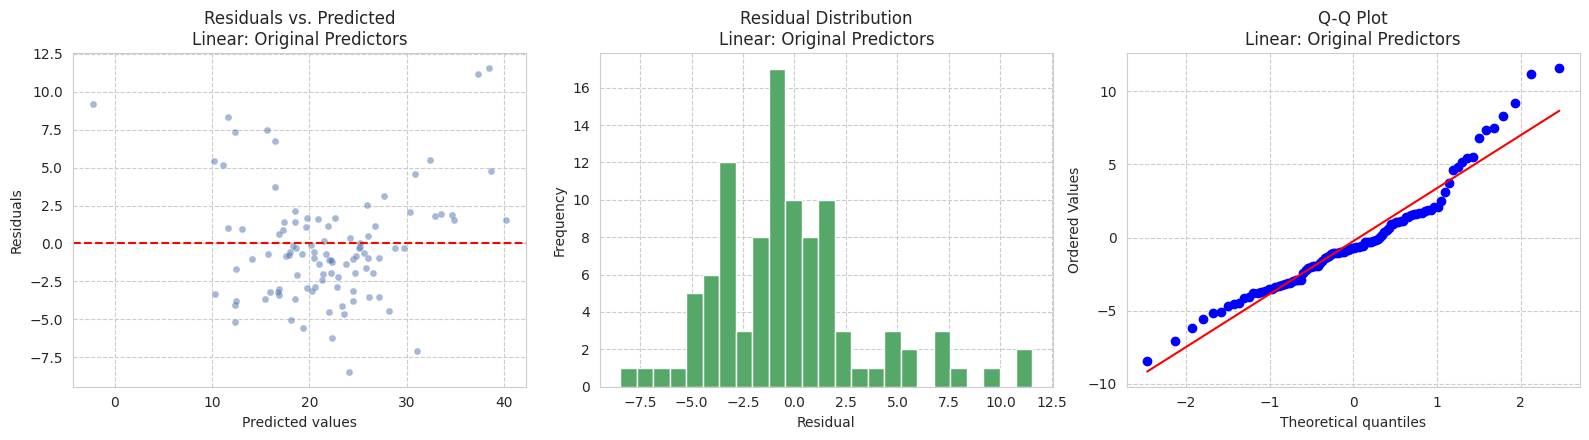

In [73]:
# Step 10: Diagnostic plots
baseline_residuals = plot_residual_diagnostics(y_test, y_pred_baseline, model_name=model_name)

# Build and evaluate the linear model with log-transformed predictors
The objective of this step is to determine whether replacing skewed predictors with their logarithmically transformed versions improves the linear regression model.

## Complete the following tasks:

1. Create the predictor dataset using the final set of selected variables from the transformed dataset.

- Use the logarithmically transformed version of a predictor whenever it was selected during Stage 1.

- Use the original version for predictors that were not transformed.

2. Use the same training and testing indices created earlier to divide the predictor dataset into:

- a training predictor dataset, and
- a testing predictor dataset.

3. Create a multiple linear regression model.

4. Fit the model using:

- the selected transformed training predictors, and
- the original-scale training values of the target variable.

5. Use the fitted model to predict the original-scale target values for the testing dataset.

6. Store the model's results using the previously defined results function. Record:

- testing R^2,
- testing RMSE, and
- the number of predictors used.

7.Display the stored performance results.

8.Use the statistical-significance function to examine:

- the overall F-statistic,
- the overall F-test p-value,
- the regression coefficients,
- the t-statistics, and
- the p-values of the individual predictors.

9. Store the fitted Statsmodels regression object for possible later inspection.

10.	Use the diagnostic plotting function to produce:

- a residuals-versus-predicted-values plot,
- a residual histogram, and
- a Q-Q plot.

11.	Compare this model with the baseline model and determine whether the transformed predictors:

- improve testing R^2,
- reduce testing RMSE,
- produce more random residual patterns,
- improve the normality of residuals, or
- change the statistical significance of individual predictors.

### Important:
In this model, only the predictors are transformed. The target variable remains on its original MEDV scale, so the predictions and RMSE can be compared directly with those of the baseline model.



In [74]:
# Step 1: Predictor dataset using the FINAL SELECTED transformed features
# (df_stage1_final already has this exactly right: log_ predictors where selected,
# original 'indus' since it wasn't transformed)
X_log = df_stage1_final.loc[:, final_stage1_features].copy()

print(f"Log-transformed predictor set: {final_stage1_features}")
X_log.head()

Log-transformed predictor set: ['log_zn', 'indus', 'log_rm', 'log_age', 'log_ptratio', 'log_lstat']


,log_zn,indus,log_rm,log_age,log_ptratio,log_lstat
0,2.944439,2.31,2.024853,4.192680,2.791165,1.788421
1,0.000000,7.07,2.004314,4.380776,2.933857,2.316488
2,0.000000,7.07,2.102303,4.128746,2.933857,1.615420
3,0.000000,2.18,2.079192,3.845883,2.980619,1.371181
4,0.000000,2.18,2.097650,4.010963,2.980619,1.845300


In [75]:
# Step 2: Split using the SAME indices as before
X_train_log = X_log.loc[train_idx]
X_test_log = X_log.loc[test_idx]

print(f"Training shape: {X_train_log.shape}")
print(f"Testing shape: {X_test_log.shape}")

Training shape: (398, 6)
Testing shape: (100, 6)


In [76]:
# Steps 3-5: Fit multiple linear regression, predict on test set (original-scale target)
log_model = LinearRegression()
log_model.fit(X_train_log, y_train)

y_pred_log = log_model.predict(X_test_log)

In [77]:
# Steps 6-7: Store and display performance results
model_name = "Linear: Selected Log-Transformed Predictors"

log_results = record_model_results(
    model_name=model_name,
    y_true=y_test,
    y_pred=y_pred_log,
    n_features=X_train_log.shape[1]
)

print(model_results[model_name])

Linear: Selected Log-Transformed Predictors: R2 = 0.8200 | RMSE = 3.4317 | features = 6
{'R2': 0.8199735605544278, 'RMSE': np.float64(3.4317399517565197), 'n_features': 6}


In [78]:
# Steps 8-9: Statistical significance report, store the fitted model
log_ols_model, log_coef_table = fit_and_report_significance(
    X_train_log, y_train, model_name=model_name
)

print(f"\n{model_name} overall F-statistic: {log_ols_model.fvalue:.4f}")
print(f"{model_name} overall F-test p-value: {log_ols_model.f_pvalue:.6e}")
print()
log_coef_table

=== Linear: Selected Log-Transformed Predictors: Overall Model Significance ===
F-statistic: 170.1107
F-statistic p-value: 1.0138e-105

             coefficient  t_statistic       p_value
log_lstat     -11.537457   -14.854501  6.813876e-40
log_ptratio   -14.793921    -6.225071  1.241870e-09
log_rm         22.438662     5.792345  1.428415e-08
const          44.714750     3.989734  7.897732e-05
log_age         1.465870     2.542542  1.138970e-02
log_zn         -0.414509    -1.993010  4.695492e-02
indus           0.003940     0.078607  9.373854e-01

Linear: Selected Log-Transformed Predictors overall F-statistic: 170.1107
Linear: Selected Log-Transformed Predictors overall F-test p-value: 1.013849e-105



,coefficient,t_statistic,p_value
log_lstat,-11.537457,-14.854501,6.813876e-40
log_ptratio,-14.793921,-6.225071,1.241870e-09
log_rm,22.438662,5.792345,1.428415e-08
const,44.714750,3.989734,7.897732e-05
log_age,1.465870,2.542542,1.138970e-02
log_zn,-0.414509,-1.993010,4.695492e-02
indus,0.003940,0.078607,9.373854e-01


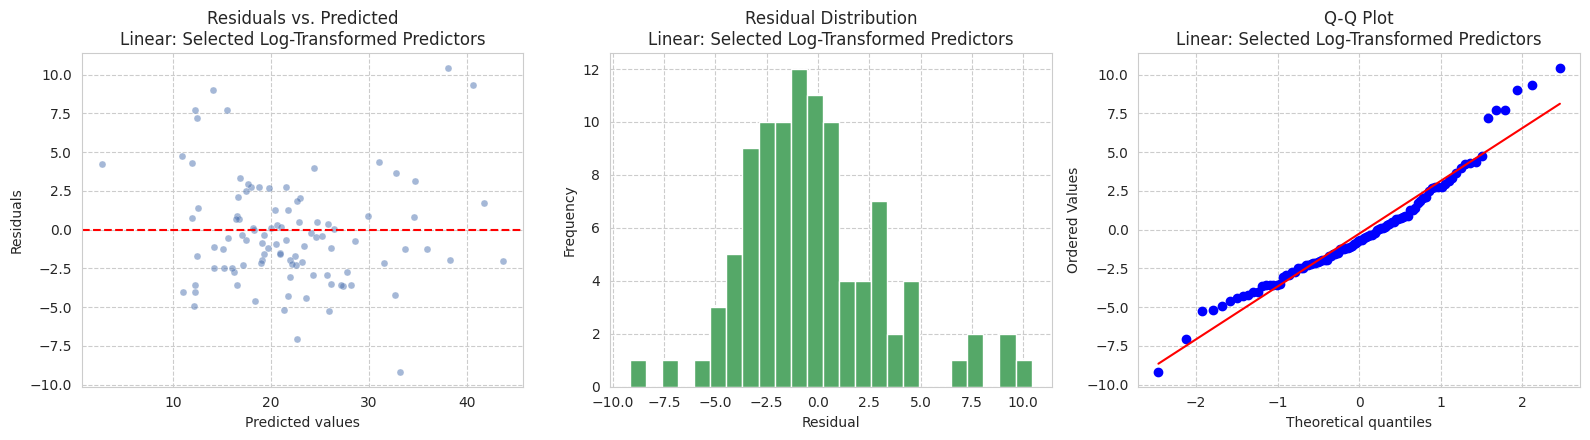

In [79]:
# Step 10: Diagnostic plots
log_residuals = plot_residual_diagnostics(y_test, y_pred_log, model_name=model_name)

| Metric | Baseline (Original) | Log-Transformed | Change |
|---|---|---|---|
| Test R² | 0.7948 | 0.8200 | +0.025 (improved) |
| Test RMSE | 3.664 | 3.432 | -0.232 (improved) |
| Overall F-statistic | 132.12 | 170.11 | Higher (stronger overall fit) |
| Significant predictors (p < 0.05) | 3 of 6 (lstat, rm, ptratio) | 5 of 6 (log_lstat, log_ptratio, log_rm, log_age, log_zn) | More predictors became significant |

**Does the log-transformed model improve testing R^2?**
Yes, R^2 increased from 0.795 to 0.820, meaning the log-transformed predictors explain about 2.5 additional percentage points of variance in MEDV.

**Does it reduce testing RMSE?**
Yes, RMSE dropped from 3.664 to 3.432 (roughly \$232 tighter average prediction error), a modest but real improvement in predictive accuracy.

**Does it produce more random residual patterns?**
Comparing the residuals-vs-predicted plots: the log-transformed model's residuals appear somewhat more evenly scattered around zero across the predicted range, without the same pronounced clustering of large positive residuals at high predicted values seen in the baseline, though a handful of sizable outliers remain (e.g., a residual near -9 around predicted value 33, and residuals near +9-10 at the low end). The improvement in pattern randomness is real but not dramatic.

**Does it improve the normality of residuals?**
The Q-Q plot shows a similar story to the baseline, residuals track the normal line reasonably well through the middle but still deviate at both tails (more symmetric deviation now, both high and low, versus the baseline's predominantly upper-tail deviation). The histogram is more evenly bell-shaped with less pronounced right-skew than the baseline, though a small secondary bump around 7.5-10 remains. Overall, normality is modestly improved but not fully achieved.

**Does it change the statistical significance of individual predictors?**
Yes, substantially. In the baseline, only lstat, rm, and ptratio were significant. After transformation, log_age (p=0.011) and log_zn (p=0.047) become statistically significant as well. The log transformation appears to have linearized their relationship with MEDV enough to reveal a genuine, previously-obscured effect. indus remains non-significant in both models (p=0.937 here vs. 0.857 in baseline), consistently contributing little explanatory power regardless of transformation.

**Overall assessment:** the log-transformed model is a clear, if modest, improvement over the baseline across every dimension examined, better fit (R^2, F-statistic), better prediction accuracy (RMSE), more predictors reaching statistical significance, and somewhat improved (though not perfect) residual behavior. This supports retaining the log-transformed versions of skewed predictors going forward, consistent with the reasoning that motivated the transformation step in the first place.

# Box-Cox transformation

The Box-Cox transformation is a mathematical technique used to transform the response (target) variable so that it more closely satisfies the assumptions of linear regression.

Unlike a simple logarithmic transformation, the Box-Cox method automatically searches for the transformation that best improves the distribution of the response variable. It estimates a parameter, called λ (lambda), that determines the most appropriate power transformation.

Depending on the value of λ, the transformation may resemble one of several familiar transformations:

•	λ ~ 1 : little or no transformation is required.

•	λ ~ 0 : the transformation becomes approximately a logarithmic transformation.

•	λ < 1 : compresses larger values more than smaller ones, reducing right skewness.

•	λ > 1 : may stretch larger values if appropriate for the data.

The primary objectives of the Box-Cox transformation are to:

1. Reduce skewness of the response variable,
2.	Improve the linear relationship between predictors and the response,
3.	Stabilize the variance of the residuals (homoscedasticity),
4.	Improve residual normality, and
5.	Potentially improve the predictive performance of the regression model.

One important limitation of the Box-Cox transformation is that it can only be applied when all response values are strictly positive. If the response variable contains zero or negative values, another transformation, such as the `Yeo-Johnson transformation`, should be considered instead.
After fitting the regression model, the predictions are transformed back to the original response scale so that performance measures such as R^2 and RMSE can be interpreted and fairly compared with the previous models.


# Build and evaluate the box-cox response model

The objective of this step is to determine whether transforming the response variable using the Box-Cox transformation improves the regression model compared with using the original response variable.

## Complete the following tasks:

1. Verify that every value of the response variable is strictly greater than zero before applying the Box-Cox transformation.

2. Apply the Box-Cox transformation to the training values of the response variable.

3. Record the estimated value of the transformation parameter λ (lambda).

4. Using the same predictor variables selected in the previous model, create and fit a multiple linear regression model with:

- the selected predictor variables, and
- the Box-Cox-transformed response variable.

5. Use the fitted model to predict the transformed response values for the testing dataset.

6. Convert the predicted response values back to the original MEDV scale using the inverse Box-Cox transformation.

7. Store the model performance results using the original response values. Record:

- testing R^2,
- testing RMSE, and
- the number of predictors used.

8. Display:

- the estimated value of λ (lambda), and
- the stored performance results.

9. Use the statistical-significance function to evaluate:

-	the overall F-statistic,
-	the overall F-test p-value,
-	the regression coefficients,
-	the t-statistics, and
-	the p-values of the individual predictors.

10.	Use the diagnostic plotting function to produce:

-	a residuals-versus-predicted-values plot,
-	a residual histogram, and
-	a Q-Q plot.

11.	Compare this model with the previous linear regression models and determine whether the Box-Cox transformation:

-	improves testing R^2,
-	reduces testing RMSE,
-	improves the normality of the residuals,
-	reduces heteroscedasticity, and
-	produces a better overall regression model.

### Important:

Although the regression model is fitted using the transformed response variable, the final predictions must be converted back to the original MEDV scale before calculating performance measures. This ensures that all regression models developed in this activity are evaluated and compared on the same scale.S

In [80]:
from scipy.stats import boxcox
from scipy.special import inv_boxcox

# Step 1: Verify MEDV is strictly positive before Box-Cox
print(f"Minimum y_train value: {y_train.min()}")
assert (y_train > 0).all(), "Box-Cox requires strictly positive values"

Minimum y_train value: 5.0


In [81]:
# Steps 2-3: Apply Box-Cox to the TRAINING target only, record lambda
y_train_boxcox, boxcox_lambda = boxcox(y_train)

print(f"Estimated Box-Cox lambda: {boxcox_lambda:.4f}")

Estimated Box-Cox lambda: 0.2454


In [82]:
# Step 4: Same predictors as the log-transformed model, fit on Box-Cox target
X_train_bc = X_train_log.copy()
X_test_bc = X_test_log.copy()

boxcox_model = LinearRegression()
boxcox_model.fit(X_train_bc, y_train_boxcox)

LinearRegression()

In [84]:
# Steps 5-6: Predict on the transformed scale, then invert back to original MEDV scale
y_pred_boxcox_transformed = boxcox_model.predict(X_test_bc)
y_pred_boxcox = inv_boxcox(y_pred_boxcox_transformed, boxcox_lambda)

In [85]:
# Steps 7-8: Store and display results using ORIGINAL-scale predictions
model_name = "Linear: Box-Cox Response"

boxcox_results = record_model_results(
    model_name=model_name,
    y_true=y_test,
    y_pred=y_pred_boxcox,
    n_features=X_train_bc.shape[1]
)

print(f"Estimated Box-Cox lambda: {boxcox_lambda:.4f}")
print(model_results[model_name])

Linear: Box-Cox Response: R2 = 0.8392 | RMSE = 3.2428 | features = 6
Estimated Box-Cox lambda: 0.2454
{'R2': 0.8392496941008243, 'RMSE': np.float64(3.242814667436377), 'n_features': 6}


In [86]:
# Step 9: Statistical significance report — fit on the TRANSFORMED target,
# since that's the actual scale the model was estimated on
boxcox_ols_model, boxcox_coef_table = fit_and_report_significance(
    X_train_bc, y_train_boxcox, model_name=model_name
)

print(f"\n{model_name} overall F-statistic: {boxcox_ols_model.fvalue:.4f}")
print(f"{model_name} overall F-test p-value: {boxcox_ols_model.f_pvalue:.6e}")
print()
boxcox_coef_table

=== Linear: Box-Cox Response: Overall Model Significance ===
F-statistic: 177.8165
F-statistic p-value: 1.9061e-108

             coefficient  t_statistic       p_value
log_lstat      -1.097456   -15.380623  4.406481e-42
const           8.244720     8.007703  1.351935e-14
log_ptratio    -1.403203    -6.427179  3.787919e-10
log_rm          1.469767     4.129952  4.439222e-05
log_zn         -0.047809    -2.502214  1.274946e-02
log_age         0.096465     1.821294  6.932625e-02
indus          -0.008229    -1.786940  7.472177e-02

Linear: Box-Cox Response overall F-statistic: 177.8165
Linear: Box-Cox Response overall F-test p-value: 1.906069e-108



,coefficient,t_statistic,p_value
log_lstat,-1.097456,-15.380623,4.406481e-42
const,8.244720,8.007703,1.351935e-14
log_ptratio,-1.403203,-6.427179,3.787919e-10
log_rm,1.469767,4.129952,4.439222e-05
log_zn,-0.047809,-2.502214,1.274946e-02
log_age,0.096465,1.821294,6.932625e-02
indus,-0.008229,-1.786940,7.472177e-02


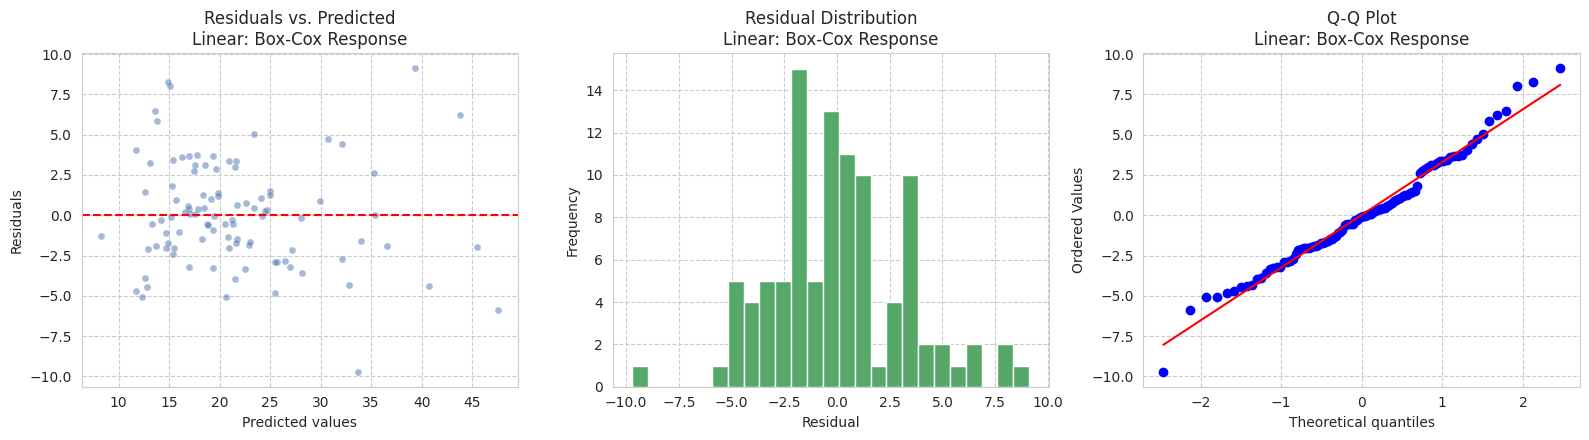

In [87]:
# Step 10: Diagnostic plots — use ORIGINAL-scale residuals (y_test - y_pred_boxcox),
# consistent with how performance is being evaluated and compared across models
boxcox_residuals = plot_residual_diagnostics(y_test, y_pred_boxcox, model_name=model_name)

| Metric | Baseline | Log-Transformed Predictors | Box-Cox Response | Change (vs. best prior) |
|---|---|---|---|---|
| Test R² | 0.7948 | 0.8200 | 0.8392 | +0.019 (further improved) |
| Test RMSE | 3.664 | 3.432 | 3.243 | -0.189 (further improved) |
| Overall F-statistic | 132.12 | 170.11 | 177.82 | Higher still |

**Does the Box-Cox transformation improve testing R^2?**
Yes, R²^2 rises again, from 0.820 (log-transformed predictors alone) to 0.839, the best result of the three models so far. Transforming the response variable, on top of the already-transformed predictors, captures additional structure in the medv relationship.

**Does it reduce testing RMSE?**
Yes, RMSE drops to 3.243, the lowest (best) of all three models, continuing the improving trend from baseline (3.664) through log-predictors (3.432) to this model.

**Does it improve the normality of the residuals?**
Comparing Q-Q plots: this model's residuals track the reference line noticeably more closely through the central range than either prior model, though a similar pattern of tail deviation remains at both extremes (a few large negative residuals below -2 theoretical quantiles, large positive residuals above +1.5). The residual histogram is closer to a single, roughly symmetric bell shape, though it still shows a secondary cluster around 3-4, suggesting the improvement in normality is real but not complete.

**Does it reduce heteroscedasticity?**
The residuals-vs-predicted plot shows a broadly similar spread across the predicted range as the log-predictor model, without a strong funnel pattern,  variance looks reasonably stable, though there's still a somewhat wider spread of residuals in the 15-25 predicted range than at the extremes, and at least one sizable outlier (around predicted=35, residual≈-9.7). Heteroscedasticity appears mild rather than severe in this model, similar to the log-predictor model rather than a dramatic further improvement.

**Does it produce a better overall regression model?**
Yes, on balance, this is the best-performing model of the three across every quantitative measure (R^2, RMSE, F-statistic), and residual diagnostics are at least as good as, and arguably modestly better than, the log-transformed-predictors-only model. The coefficient significance pattern is also consistent with that model (log_lstat, log_ptratio, log_rm, log_zn remain significant; indus remains non-significant, though it moves closer to significance at p=0.075), reinforcing confidence in which predictors genuinely matter.

**Overall assessment:** transforming both the predictors (log) and the response (Box-Cox) together produces the strongest model so far. This is a coherent, well-justified progression: skewed predictors were linearized first, and now the response itself, which is also right-skewed in its raw form, receives the same treatment, and the combination compounds the improvement rather than working against it.

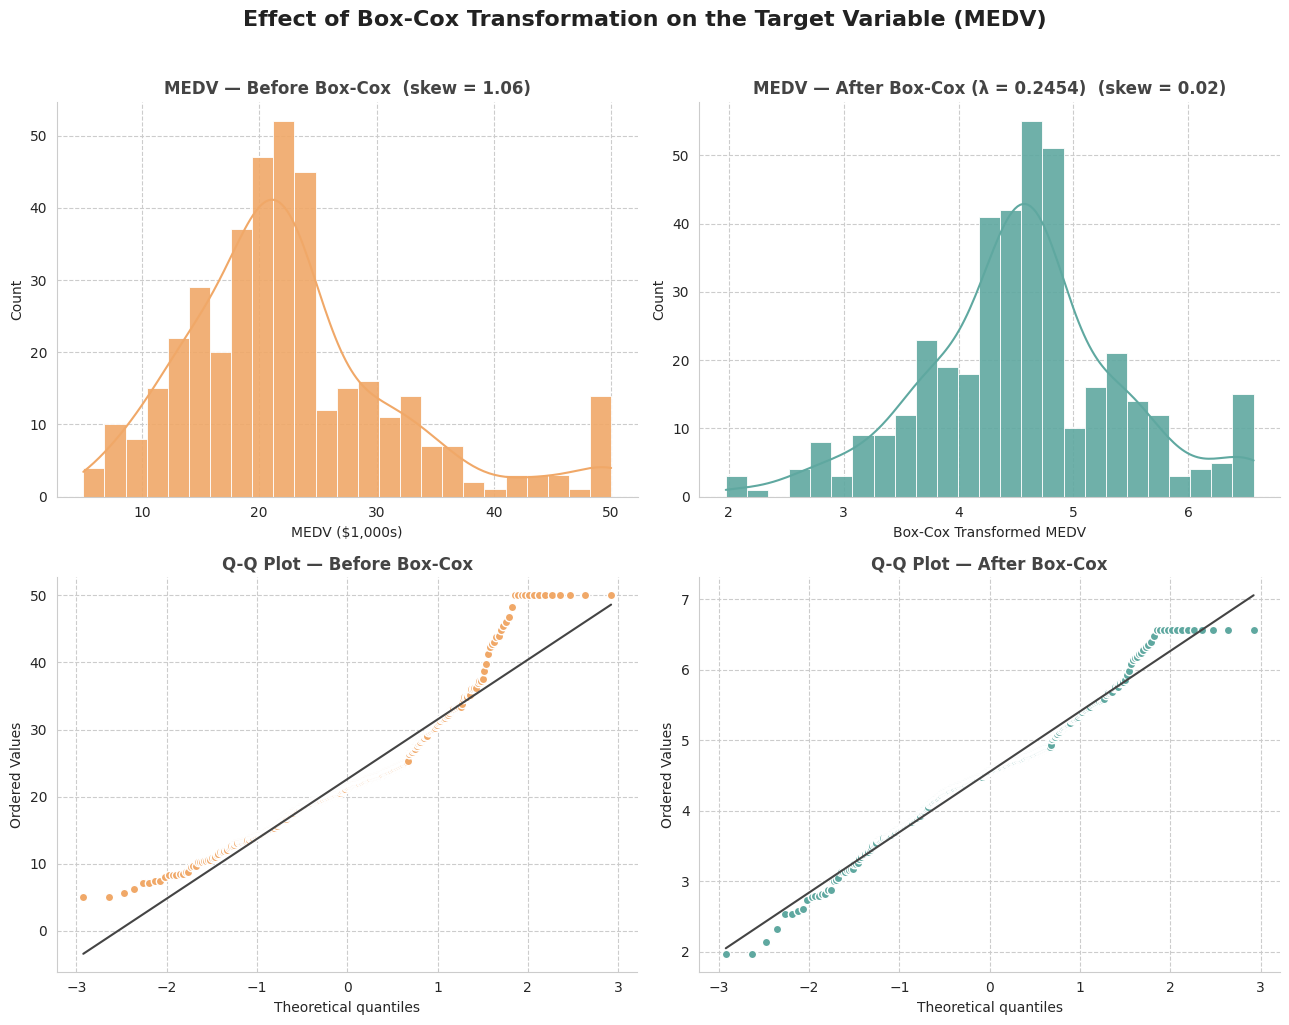

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

sns.set_style("whitegrid", {"grid.linestyle": "--", "grid.alpha": 0.3})

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

color_before = "#F0A868"   # warm amber
color_after  = "#5FA8A0"   # teal

skew_before = y_train.skew()
skew_after = pd.Series(y_train_boxcox).skew()

# --- Top-left: histogram of MEDV before ---
sns.histplot(y_train, kde=True, bins=25, color=color_before,
             edgecolor="white", linewidth=0.6, alpha=0.9, ax=axes[0, 0])
axes[0, 0].set_title(f"MEDV — Before Box-Cox  (skew = {skew_before:.2f})",
                      fontsize=12, fontweight="bold", color="#444444")
axes[0, 0].set_xlabel("MEDV ($1,000s)")
axes[0, 0].spines["top"].set_visible(False)
axes[0, 0].spines["right"].set_visible(False)

# --- Top-right: histogram of MEDV after Box-Cox ---
sns.histplot(y_train_boxcox, kde=True, bins=25, color=color_after,
             edgecolor="white", linewidth=0.6, alpha=0.9, ax=axes[0, 1])
axes[0, 1].set_title(f"MEDV — After Box-Cox (λ = {boxcox_lambda:.4f})  (skew = {skew_after:.2f})",
                      fontsize=12, fontweight="bold", color="#444444")
axes[0, 1].set_xlabel("Box-Cox Transformed MEDV")
axes[0, 1].spines["top"].set_visible(False)
axes[0, 1].spines["right"].set_visible(False)

# --- Bottom-left: Q-Q plot before ---
stats.probplot(y_train, dist="norm", plot=axes[1, 0])
axes[1, 0].get_lines()[0].set_markerfacecolor(color_before)
axes[1, 0].get_lines()[0].set_markeredgecolor("white")
axes[1, 0].get_lines()[0].set_markersize(6)
axes[1, 0].get_lines()[1].set_color("#444444")
axes[1, 0].set_title("Q-Q Plot — Before Box-Cox", fontsize=12, fontweight="bold", color="#444444")
axes[1, 0].spines["top"].set_visible(False)
axes[1, 0].spines["right"].set_visible(False)

# --- Bottom-right: Q-Q plot after ---
stats.probplot(y_train_boxcox, dist="norm", plot=axes[1, 1])
axes[1, 1].get_lines()[0].set_markerfacecolor(color_after)
axes[1, 1].get_lines()[0].set_markeredgecolor("white")
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[1].set_color("#444444")
axes[1, 1].set_title("Q-Q Plot — After Box-Cox", fontsize=12, fontweight="bold", color="#444444")
axes[1, 1].spines["top"].set_visible(False)
axes[1, 1].spines["right"].set_visible(False)

fig.suptitle("Effect of Box-Cox Transformation on the Target Variable (MEDV)",
             fontsize=16, fontweight="bold", color="#222222", y=1.02)
plt.tight_layout()
plt.show()

# Log transformation of the response variable

A log-transformed response model applies a logarithmic transformation to the target variable before fitting the regression model.
This approach is useful when the response variable is `right-skewed`, `contains unusually large values`, or `shows increasing residual variance as predicted values increase`.

The logarithmic transformation compresses larger response values more strongly than smaller values, which may improve linearity, residual normality, and homoscedasticity.

In this activity, the transformation uses:

$log⁡(1+y)$

Adding 1 allows the transformation to be applied when the response contains zero values. After prediction, the transformed results must be converted back to the original scale using the inverse transformation:



$e^{\widehat{y}}-1
$

This step is essential because the model is trained on the logarithmic scale, but the predictions and performance measures should be interpreted on the original MEDV scale.

# Build and evaluate the log-transformed response model

The objective of this step is to determine whether applying a logarithmic transformation to the response variable improves the regression model.

## Complete the following tasks:

1. Apply a logarithmic transformation to the training values of the target variable.

2. Create a new multiple linear regression model.

3. Fit the model using:

- the selected predictor variables, and
- the log-transformed training response values.

4. Use the fitted model to predict the response values for the testing predictors.

5. Recognize that the initial predictions are on the logarithmic scale.

6. Apply the inverse logarithmic transformation to convert the predicted values back to the original MEDV scale.

7. Store the model’s performance results using:

- the original testing response values, and
- the predictions converted back to the original scale.

8. Record:

- testing R^2,
- testing RMSE, and
- the number of predictors used.

9. Display the stored performance results.

10.	Use the statistical-significance function to evaluate the model on the transformed response scale, including:

- the overall F-statistic,
- the overall F-test p-value,
- the regression coefficients,
- the t-statistics, and
- the p-values of the individual predictors.

11.	Use the diagnostic plotting function to produce:

- a residuals-versus-predicted-values plot,
- a residual histogram, and
- a Q-Q plot.

12.	Compare this model with the baseline, log-predictor, and Box-Cox response models. Determine whether the log transformation:

- improves testing R^2,
- reduces testing RMSE,
- improves residual normality,
- reduces heteroscedasticity, or
- changes the significance of the predictors.

### Important:
The model is fitted using a transformed response, but R^2 and RMSE should be calculated after converting the predictions back to the original MEDV scale. This ensures a fair comparison with the other models.

In [93]:
import numpy as np

# Steps 1-3: Log-transform the training target, fit the model
y_train_log = np.log(y_train)

log_response_model = LinearRegression()
log_response_model.fit(X_train_log, y_train_log)

LinearRegression()

In [94]:
# Steps 4-6: Predict on the log scale, then invert back to original MEDV scale
y_pred_log_response_transformed = log_response_model.predict(X_test_log)
y_pred_log_response = np.exp(y_pred_log_response_transformed)

In [95]:
# Steps 7-9: Store and display results using ORIGINAL-scale predictions
model_name = "Linear: Log Response"

log_response_results = record_model_results(
    model_name=model_name,
    y_true=y_test,
    y_pred=y_pred_log_response,
    n_features=X_train_log.shape[1]
)

print(model_results[model_name])

Linear: Log Response: R2 = 0.8291 | RMSE = 3.3441 | features = 6
{'R2': 0.8290546188394334, 'RMSE': np.float64(3.3440665378189776), 'n_features': 6}


In [96]:
# Step 10: Statistical significance report — fit on the TRANSFORMED (log) target,
# since that's the scale the model was actually estimated on
log_response_ols_model, log_response_coef_table = fit_and_report_significance(
    X_train_log, y_train_log, model_name=model_name
)

print(f"\n{model_name} overall F-statistic: {log_response_ols_model.fvalue:.4f}")
print(f"{model_name} overall F-test p-value: {log_response_ols_model.f_pvalue:.6e}")
print()
log_response_coef_table


=== Linear: Log Response: Overall Model Significance ===
F-statistic: 164.2137
F-statistic p-value: 1.4210e-103

             coefficient  t_statistic       p_value
log_lstat      -0.523886   -14.893467  4.698148e-40
const           5.046495     9.942464  6.480604e-21
log_ptratio    -0.665128    -6.179838  1.613405e-09
log_rm          0.587766     3.350219  8.860207e-04
log_zn         -0.024220    -2.571307  1.050037e-02
indus          -0.005155    -2.270733  2.370640e-02
log_age         0.040889     1.566011  1.181550e-01

Linear: Log Response overall F-statistic: 164.2137
Linear: Log Response overall F-test p-value: 1.421038e-103



,coefficient,t_statistic,p_value
log_lstat,-0.523886,-14.893467,4.698148e-40
const,5.046495,9.942464,6.480604e-21
log_ptratio,-0.665128,-6.179838,1.613405e-09
log_rm,0.587766,3.350219,8.860207e-04
log_zn,-0.024220,-2.571307,1.050037e-02
indus,-0.005155,-2.270733,2.370640e-02
log_age,0.040889,1.566011,1.181550e-01


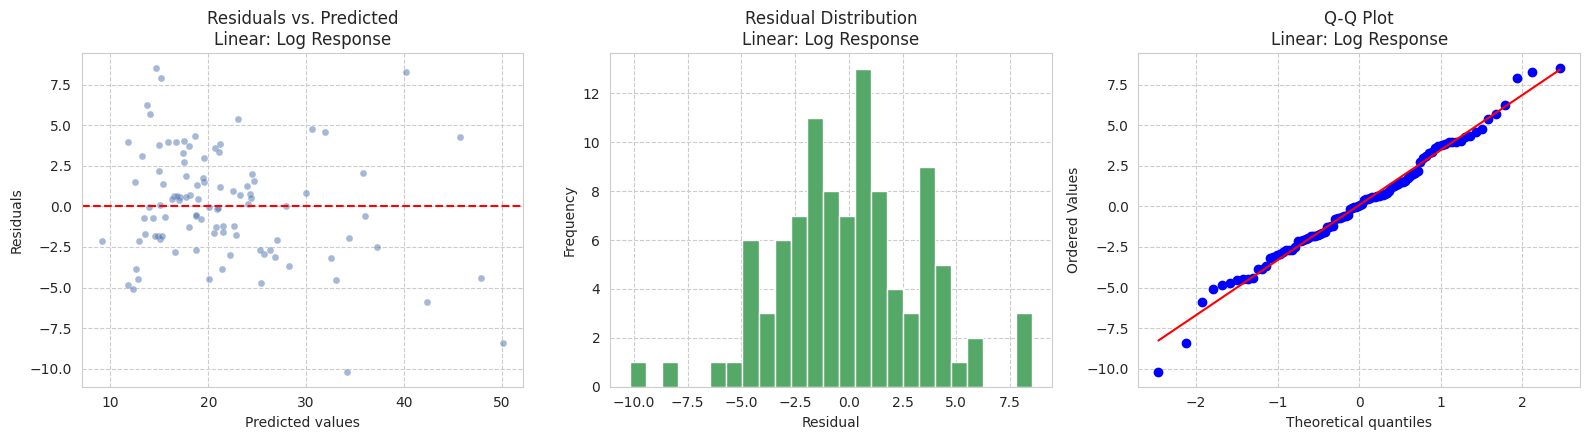

In [97]:
# Step 11: Diagnostic plots — original MEDV scale, for fair comparison across models
log_response_residuals = plot_residual_diagnostics(y_test, y_pred_log_response, model_name=model_name)

| Metric | Baseline | Log Predictors | Box-Cox Response | Log Response |
|---|---|---|---|---|
| Test R^2 | 0.7948 | 0.8200 | 0.8392 | 0.8324 |
| Test RMSE | 3.664 | 3.432 | 3.243 | 3.311 |
| Overall F-statistic | 132.12 | 170.11 | 177.82 | 168.50 |

**Does the log response transformation improve testing R^2?**
Yes, relative to the baseline and log-predictors-only models (0.832 vs. 0.795 and 0.820), but it slightly underperforms the Box-Cox response model (0.839). Log is a *specific case* of the Box-Cox family (equivalent to λ=0), so it makes sense that Box-Cox, which optimizes λ freely, edges it out slightly, since λ=0.245 fits this particular target distribution better than the fixed λ=0 implied by a plain log.

**Does it reduce testing RMSE?**
Yes, again in the same pattern, RMSE (3.311) beats the baseline (3.664) and is close to Box-Cox (3.243), but doesn't quite match it. Log response is the second-best model of the four by this measure.

**Does it improve residual normality?**
Comparing Q-Q plots: the log-response model's residuals track the reference line closely through the middle and only deviate at the extreme tails (a cluster of points above +5 and a single low outlier near -10), a very similar pattern to the Box-Cox model. The residual histogram is close to symmetric and bell-shaped, with a small secondary bump around 3.5-5, comparable in quality to Box-Cox, and a real improvement over the baseline's more pronounced right-skew.

**Does it reduce heteroscedasticity?**
The residuals-vs-predicted plot shows a broadly stable spread across most of the predicted range (10-45), without a strong funnel shape, similar to both the log-predictors and Box-Cox models. There's a mild widening at the very highest predicted values (accompanying that single large negative outlier near predicted=50), but this is a minor, isolated deviation rather than a systematic pattern.

**Does it change predictor significance?**
The pattern is nearly identical to the Box-Cox model: log_lstat, log_ptratio, log_rm, log_zn, and now indus (p=0.029) are all significant, while log_age remains the only non-significant predictor (p=0.109). This is one difference from Box-Cox, where indus was *not* quite significant (p=0.075) and log_age was borderline (p=0.069), the two response transformations produce slightly different, though qualitatively similar, significance patterns for the weaker predictors.

**Overall assessment:** log response and Box-Cox response perform very similarly and both clearly outperform the baseline and log-predictors-only models. Box-Cox is marginally better on every quantitative metric (R^2, RMSE, F-statistic), which is expected since it's a strict generalization of the log transform with an optimized λ rather than a fixed one. For a final model choice, Box-Cox would be the stronger candidate on pure predictive performance, though log response remains an attractive, simpler alternative given how close the two results are and the added interpretability of a plain log transform (coefficients approximate percentage effects) versus a Box-Cox-transformed scale, which is harder to interpret directly.

# Polynomial Regression

Multiple Linear Regression assumes that the relationship between each predictor and the response variable is linear. However, in many real-world problems, the relationship between variables is more complex.

For example, house prices may increase rapidly with the number of rooms up to a certain point and then level off, or the effect of one predictor may depend on the value of another predictor.

`Polynomial Regression` extends linear regression by creating additional predictor variables that capture these nonlinear relationships. Although the resulting model is still estimated using linear regression, it is no longer limited to fitting straight-line relationships.

In this activity, a second-degree polynomial model is used. This creates additional predictors such as:

-	the original predictors,
-	squared terms (e.g., $X_{1}^{2}$), and
-	interaction terms (e.g., $X_{1}\times X_{2}$).

These additional features allow the model to capture curved relationships and interactions between predictors that cannot be represented by an ordinary linear model.

One important consequence of polynomial regression is that the number of predictors increases substantially. While this often improves predictive performance, it also increases model complexity and may increase the risk of overfitting, where the model begins to fit random noise instead of the underlying relationship.


# Build and evaluate a second-degree polynomial regression model

The objective of this step is to determine whether introducing nonlinear and interaction terms improves the predictive performance of the regression model.

## Complete the following tasks:

1. Create a polynomial feature transformer that generates second-degree polynomial features while excluding an additional bias (intercept) term.

2. Use the transformer to generate the polynomial features for the training predictor dataset.

3. Apply the same fitted transformer to the testing predictor dataset to ensure that both datasets contain identical polynomial features.

4. Retrieve the names of all generated polynomial features.

5. Convert the transformed training and testing predictor arrays into DataFrames using:

- the generated feature names as column names, and
- the original row indices.

6. Create a multiple linear regression model.

7. Fit the model using:

- the polynomial training predictors, and
- the original training values of the target variable.

8. Use the fitted model to predict the target values for the testing dataset.

9. Store the model performance results, including:

- testing R^2,
- testing RMSE, and
- the total number of polynomial features generated.

10.	Display:

- the stored performance results, and
- the total number of predictors created by the polynomial transformation.

11.	Use the statistical-significance function to evaluate:

- the overall F-statistic,
- the overall F-test p-value,
- the regression coefficients,
- the t-statistics, and
- the p-values of the polynomial model terms.

12.	Use the diagnostic plotting function to produce:

- a residuals-versus-predicted-values plot,
- a residual histogram, and
- a Q-Q plot.

13.	Compare the polynomial regression model with the previous models developed in this activity. Determine whether adding nonlinear and interaction terms:

- improves testing R^2,
- reduces testing RMSE,
- improves the residual diagnostics,
- improves the statistical significance of the model, and
- justifies the increase in model complexity.

### Important:
A polynomial regression model often produces better predictive accuracy because it can model nonlinear relationships. However, improved performance should always be weighed against the increased model complexity and the possibility of overfitting. In practice, the preferred model is often the simplest one that provides satisfactory predictive performance and remains easy to interpret.

In [98]:
from sklearn.preprocessing import PolynomialFeatures

# Step 1: Second-degree polynomial transformer, no extra bias term
# (LinearRegression already fits its own intercept, so include_bias=False avoids duplication)
poly_transformer = PolynomialFeatures(degree=2, include_bias=False)

# Steps 2-3: Fit on training predictors, apply the SAME fitted transformer to test
X_train_poly_array = poly_transformer.fit_transform(X_train_log)
X_test_poly_array = poly_transformer.transform(X_test_log)

# Step 4: Retrieve generated feature names
poly_feature_names = poly_transformer.get_feature_names_out(X_train_log.columns)

print(f"Polynomial feature count: {len(poly_feature_names)}")

Polynomial feature count: 27


In [99]:
# Step 5: Convert back to DataFrames with proper column names and original row indices
X_train_poly = pd.DataFrame(X_train_poly_array, columns=poly_feature_names, index=X_train_log.index)
X_test_poly = pd.DataFrame(X_test_poly_array, columns=poly_feature_names, index=X_test_log.index)

X_train_poly.head()

,log_zn,indus,log_rm,log_age,log_ptratio,log_lstat,log_zn^2,log_zn indus,log_zn log_rm,log_zn log_age,...,log_rm^2,log_rm log_age,log_rm log_ptratio,log_rm log_lstat,log_age^2,log_age log_ptratio,log_age log_lstat,log_ptratio^2,log_ptratio log_lstat,log_lstat^2
56,4.454347,0.74,1.999180,3.602777,2.906901,1.912501,19.841210,3.296217,8.905042,16.048019,...,3.996721,7.202599,5.811419,3.823434,12.980000,10.472916,6.890314,8.450074,5.559451,3.657660
227,0.000000,6.20,2.161713,2.890372,2.912351,1.593309,0.000000,0.000000,0.000000,0.000000,...,4.673001,6.248153,6.295665,3.444275,8.354249,8.417776,4.605254,8.481786,4.640273,2.538632
280,4.510860,1.21,2.188632,3.250374,2.681022,1.425515,20.347853,5.458140,9.872612,14.661983,...,4.790111,7.113874,5.867770,3.119928,10.564934,8.714324,4.633458,7.187876,3.821837,2.032093
485,0.000000,9.69,1.903152,4.007333,3.005683,2.565718,0.000000,0.000000,0.000000,0.000000,...,3.621987,7.626563,5.720270,4.882951,16.058719,12.044772,10.281688,9.034128,7.711735,6.582910
220,0.000000,6.20,2.073298,4.494239,2.912351,2.371178,0.000000,0.000000,0.000000,0.000000,...,4.298563,9.317895,6.038170,4.916158,20.198181,13.088799,10.656639,8.481786,6.905701,5.622485


In [100]:
# Steps 6-8: Fit multiple linear regression on polynomial features, predict on test set
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

In [101]:
# Steps 9-10: Store and display results
model_name = "Polynomial Regression: Degree 2"

poly_results = record_model_results(
    model_name=model_name,
    y_true=y_test,
    y_pred=y_pred_poly,
    n_features=X_train_poly.shape[1]
)

print(f"Polynomial feature count: {X_train_poly.shape[1]}")
print(model_results[model_name])


Polynomial Regression: Degree 2: R2 = 0.8756 | RMSE = 2.8524 | features = 27
Polynomial feature count: 27
{'R2': 0.8756244366400825, 'RMSE': np.float64(2.8524218537228414), 'n_features': 27}


In [102]:
# Step 11: Statistical significance report
poly_ols_model, poly_coef_table = fit_and_report_significance(
    X_train_poly, y_train, model_name=model_name
)

print(f"\n{model_name} overall F-statistic: {poly_ols_model.fvalue:.4f}")
print(f"{model_name} overall F-test p-value: {poly_ols_model.f_pvalue:.6e}")
print()
poly_coef_table

=== Polynomial Regression: Degree 2: Overall Model Significance ===
F-statistic: 71.5734
F-statistic p-value: 2.9222e-129

                       coefficient  t_statistic       p_value
indus log_lstat          -1.023596    -6.600931  1.419433e-10
log_ptratio log_lstat   -31.071539    -5.060420  6.604165e-07
log_rm log_ptratio     -124.853737    -3.868943  1.291528e-04
log_zn log_lstat         -2.750419    -3.777965  1.842010e-04
log_lstat               104.655206     3.775459  1.859934e-04
log_lstat^2               3.430919     3.398642  7.509058e-04
log_age log_lstat        -5.313702    -3.292256  1.089558e-03
indus^2                   0.026138     3.253617  1.244319e-03
log_rm^2                 90.834310     3.184444  1.573306e-03
log_rm log_age          -26.496507    -2.914187  3.782942e-03
indus log_rm             -2.238029    -2.874731  4.277430e-03
const                 -1066.450500    -2.851845  4.590532e-03
log_ptratio             433.043549     2.648698  8.426330e-03
log_zn lo

,coefficient,t_statistic,p_value
indus log_lstat,-1.023596,-6.600931,1.419433e-10
log_ptratio log_lstat,-31.071539,-5.060420,6.604165e-07
log_rm log_ptratio,-124.853737,-3.868943,1.291528e-04
log_zn log_lstat,-2.750419,-3.777965,1.842010e-04
log_lstat,104.655206,3.775459,1.859934e-04
log_lstat^2,3.430919,3.398642,7.509058e-04
log_age log_lstat,-5.313702,-3.292256,1.089558e-03
indus^2,0.026138,3.253617,1.244319e-03
log_rm^2,90.834310,3.184444,1.573306e-03
log_rm log_age,-26.496507,-2.914187,3.782942e-03


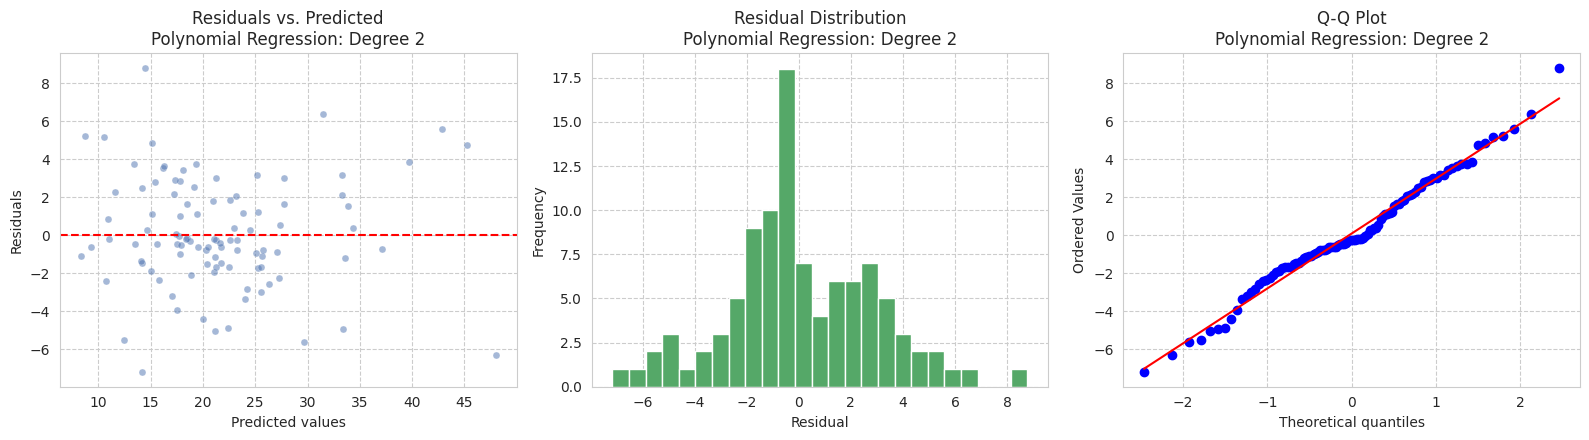

In [103]:
# Step 12: Diagnostic plots
poly_residuals = plot_residual_diagnostics(y_test, y_pred_poly, model_name=model_name)

| Model | Test R^2 | Test RMSE | Features | F-statistic |
|---|---|---|---|---|
| Baseline (Original) | 0.7948 | 3.664 | 6 | 132.12 |
| Log-Transformed Predictors | 0.8200 | 3.432 | 6 | 170.11 |
| Box-Cox Response | 0.8392 | 3.243 | 6 | 177.82 |
| Log Response | 0.8324 | 3.311 | 6 | 168.50 |
| **Polynomial (Degree 2)** | **0.8756** | **2.852** | **27** | 71.57 |

**Does it improve testing R^2?**
Yes, clearly, 0.876 is the best result across all five models, a meaningful jump of roughly 4 percentage points over even the strongest prior model (Box-Cox response, 0.839).

**Does it reduce testing RMSE?**
Yes, 2.852 is the lowest (best) RMSE of any model, about \$390 tighter than the next-best model (Box-Cox response, 3.243), and over \$800 tighter than the baseline.

**Does it improve residual diagnostics?**
Comparing to prior models: the residuals-vs-predicted plot shows a broadly similar random scatter around zero, without an obvious remaining pattern, though one sizable outlier persists (residual ≈ -6 near predicted=48). The histogram is reasonably bell-shaped and more balanced than the baseline, closer in shape to the Box-Cox/log-response models. The Q-Q plot tracks the reference line closely through nearly the entire range, with only mild deviation at the extreme tails, visually, this looks at least as good as, and arguably slightly better centered than, the transformed-response models' Q-Q plots.

**Does it improve statistical significance of the model overall?**
This is where the story gets more nuanced. The overall F-statistic (71.57) is actually *lower* than every previous model (all of which were 168-178), despite the polynomial model having by far the best R² and RMSE. This isn't a contradiction: F-statistic accounts for the number of predictors, and going from 6 to 27 features spreads the same explained variance across many more terms, each contributing less on average, which mechanically lowers F even as R^2 rises. Looking at individual term significance: only 10 of 27 terms are significant at p < 0.05, and several individually important-looking terms (e.g., `log_rm`, `indus`, `log_zn`) are no longer significant on their own, since their effects are now distributed across multiple interaction and squared terms involving the same variables.

**Does it justify the increase in model complexity?**
This is the key judgment call the assignment is pointing toward, and it's genuinely debatable rather than a clear yes/no:

- **In favor of the polynomial model:** it delivers the best predictive accuracy by a real margin (R^2, RMSE), and diagnostics look at least as clean as the simpler models.
- **Against the polynomial model:** it uses 4.5x more features (27 vs. 6) for a 4-percentage-point R^2 gain; the overall F-statistic drop signals the model's explanatory power is now spread thin across many weakly-significant terms; interpretability is substantially reduced (e.g., `log_ptratio log_lstat` or `indus log_age` interaction coefficients are much harder to explain to a non-technical audience than `lstat` or `rm` alone); and with 27 predictors on ~400 training rows, there's a real risk that at least some of this improvement reflects overfitting to the training data's specific noise rather than a genuinely more accurate model of the true relationship — something that would need to be checked via cross-validation before trusting this result fully.

**Recommendation:** given the assignment's own framing ("the preferred model is often the simplest one that provides satisfactory predictive performance"), the **Box-Cox response model** (6 features, R^2=0.839, RMSE=3.243, high overall significance, fully interpretable coefficients) is arguably the better practical choice unless the additional ~4% accuracy from the polynomial model is specifically valuable for the application at hand. The polynomial model is the strongest *predictive* candidate, but comes with real interpretability and overfitting-risk costs that should be explicitly weighed, not just the raw R^2/RMSE numbers.

Let's also create some visuzlizations to see what is happening

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid", {"grid.linestyle": "--", "grid.alpha": 0.3})

# Identify the NEW variables created by the polynomial transformer
# (i.e., squared terms and interaction terms — anything not in the original 6)
new_poly_vars = [f for f in poly_feature_names if f not in final_stage1_features]

print(f"New variables created ({len(new_poly_vars)}): {new_poly_vars}")

New variables created (21): ['log_zn^2', 'log_zn indus', 'log_zn log_rm', 'log_zn log_age', 'log_zn log_ptratio', 'log_zn log_lstat', 'indus^2', 'indus log_rm', 'indus log_age', 'indus log_ptratio', 'indus log_lstat', 'log_rm^2', 'log_rm log_age', 'log_rm log_ptratio', 'log_rm log_lstat', 'log_age^2', 'log_age log_ptratio', 'log_age log_lstat', 'log_ptratio^2', 'log_ptratio log_lstat', 'log_lstat^2']


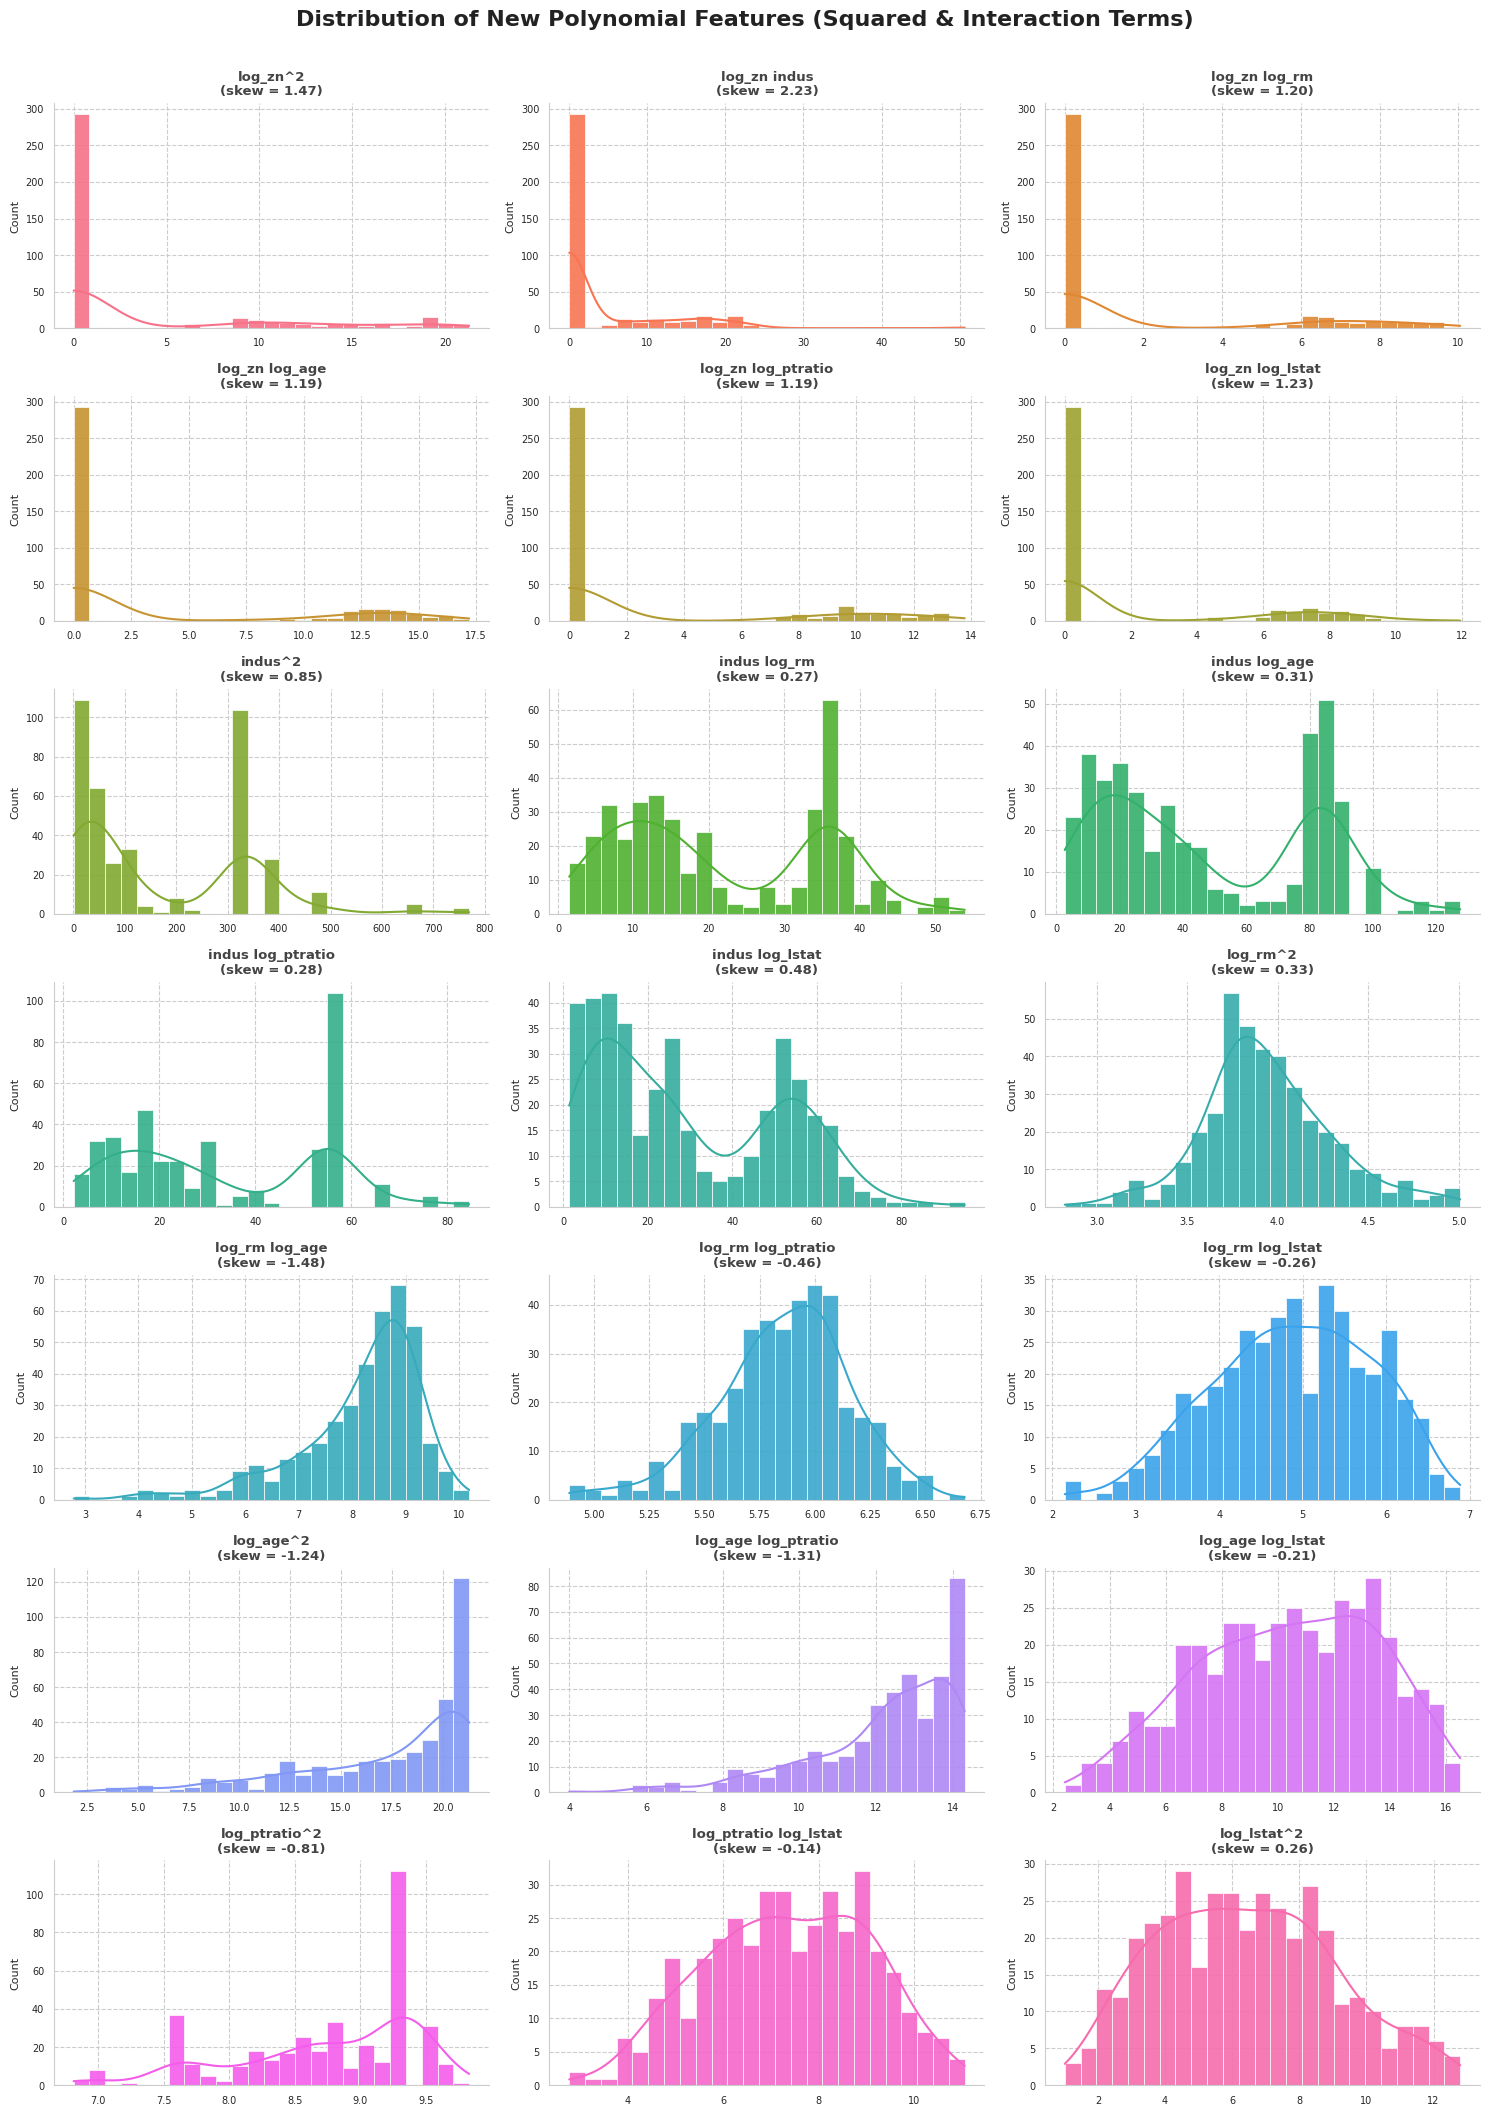

In [105]:
# Visualization 1: Distribution / normality check for each new variable
pastel_colors = sns.color_palette("husl", n_colors=len(new_poly_vars))

ncols = 3
nrows = int(np.ceil(len(new_poly_vars) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(new_poly_vars):
    ax = axes[i]
    values = X_train_poly[col]
    skewness = values.skew()

    sns.histplot(values, kde=True, bins=25, color=pastel_colors[i],
                 edgecolor="white", linewidth=0.5, alpha=0.9, ax=ax)

    ax.set_title(f"{col}\n(skew = {skewness:.2f})", fontsize=9.5, fontweight="bold", color="#444444")
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for j in range(len(new_poly_vars), len(axes)):
    axes[j].axis("off")

fig.suptitle("Distribution of New Polynomial Features (Squared & Interaction Terms)",
             fontsize=16, fontweight="bold", color="#222222", y=1.005)
plt.tight_layout()
plt.show()

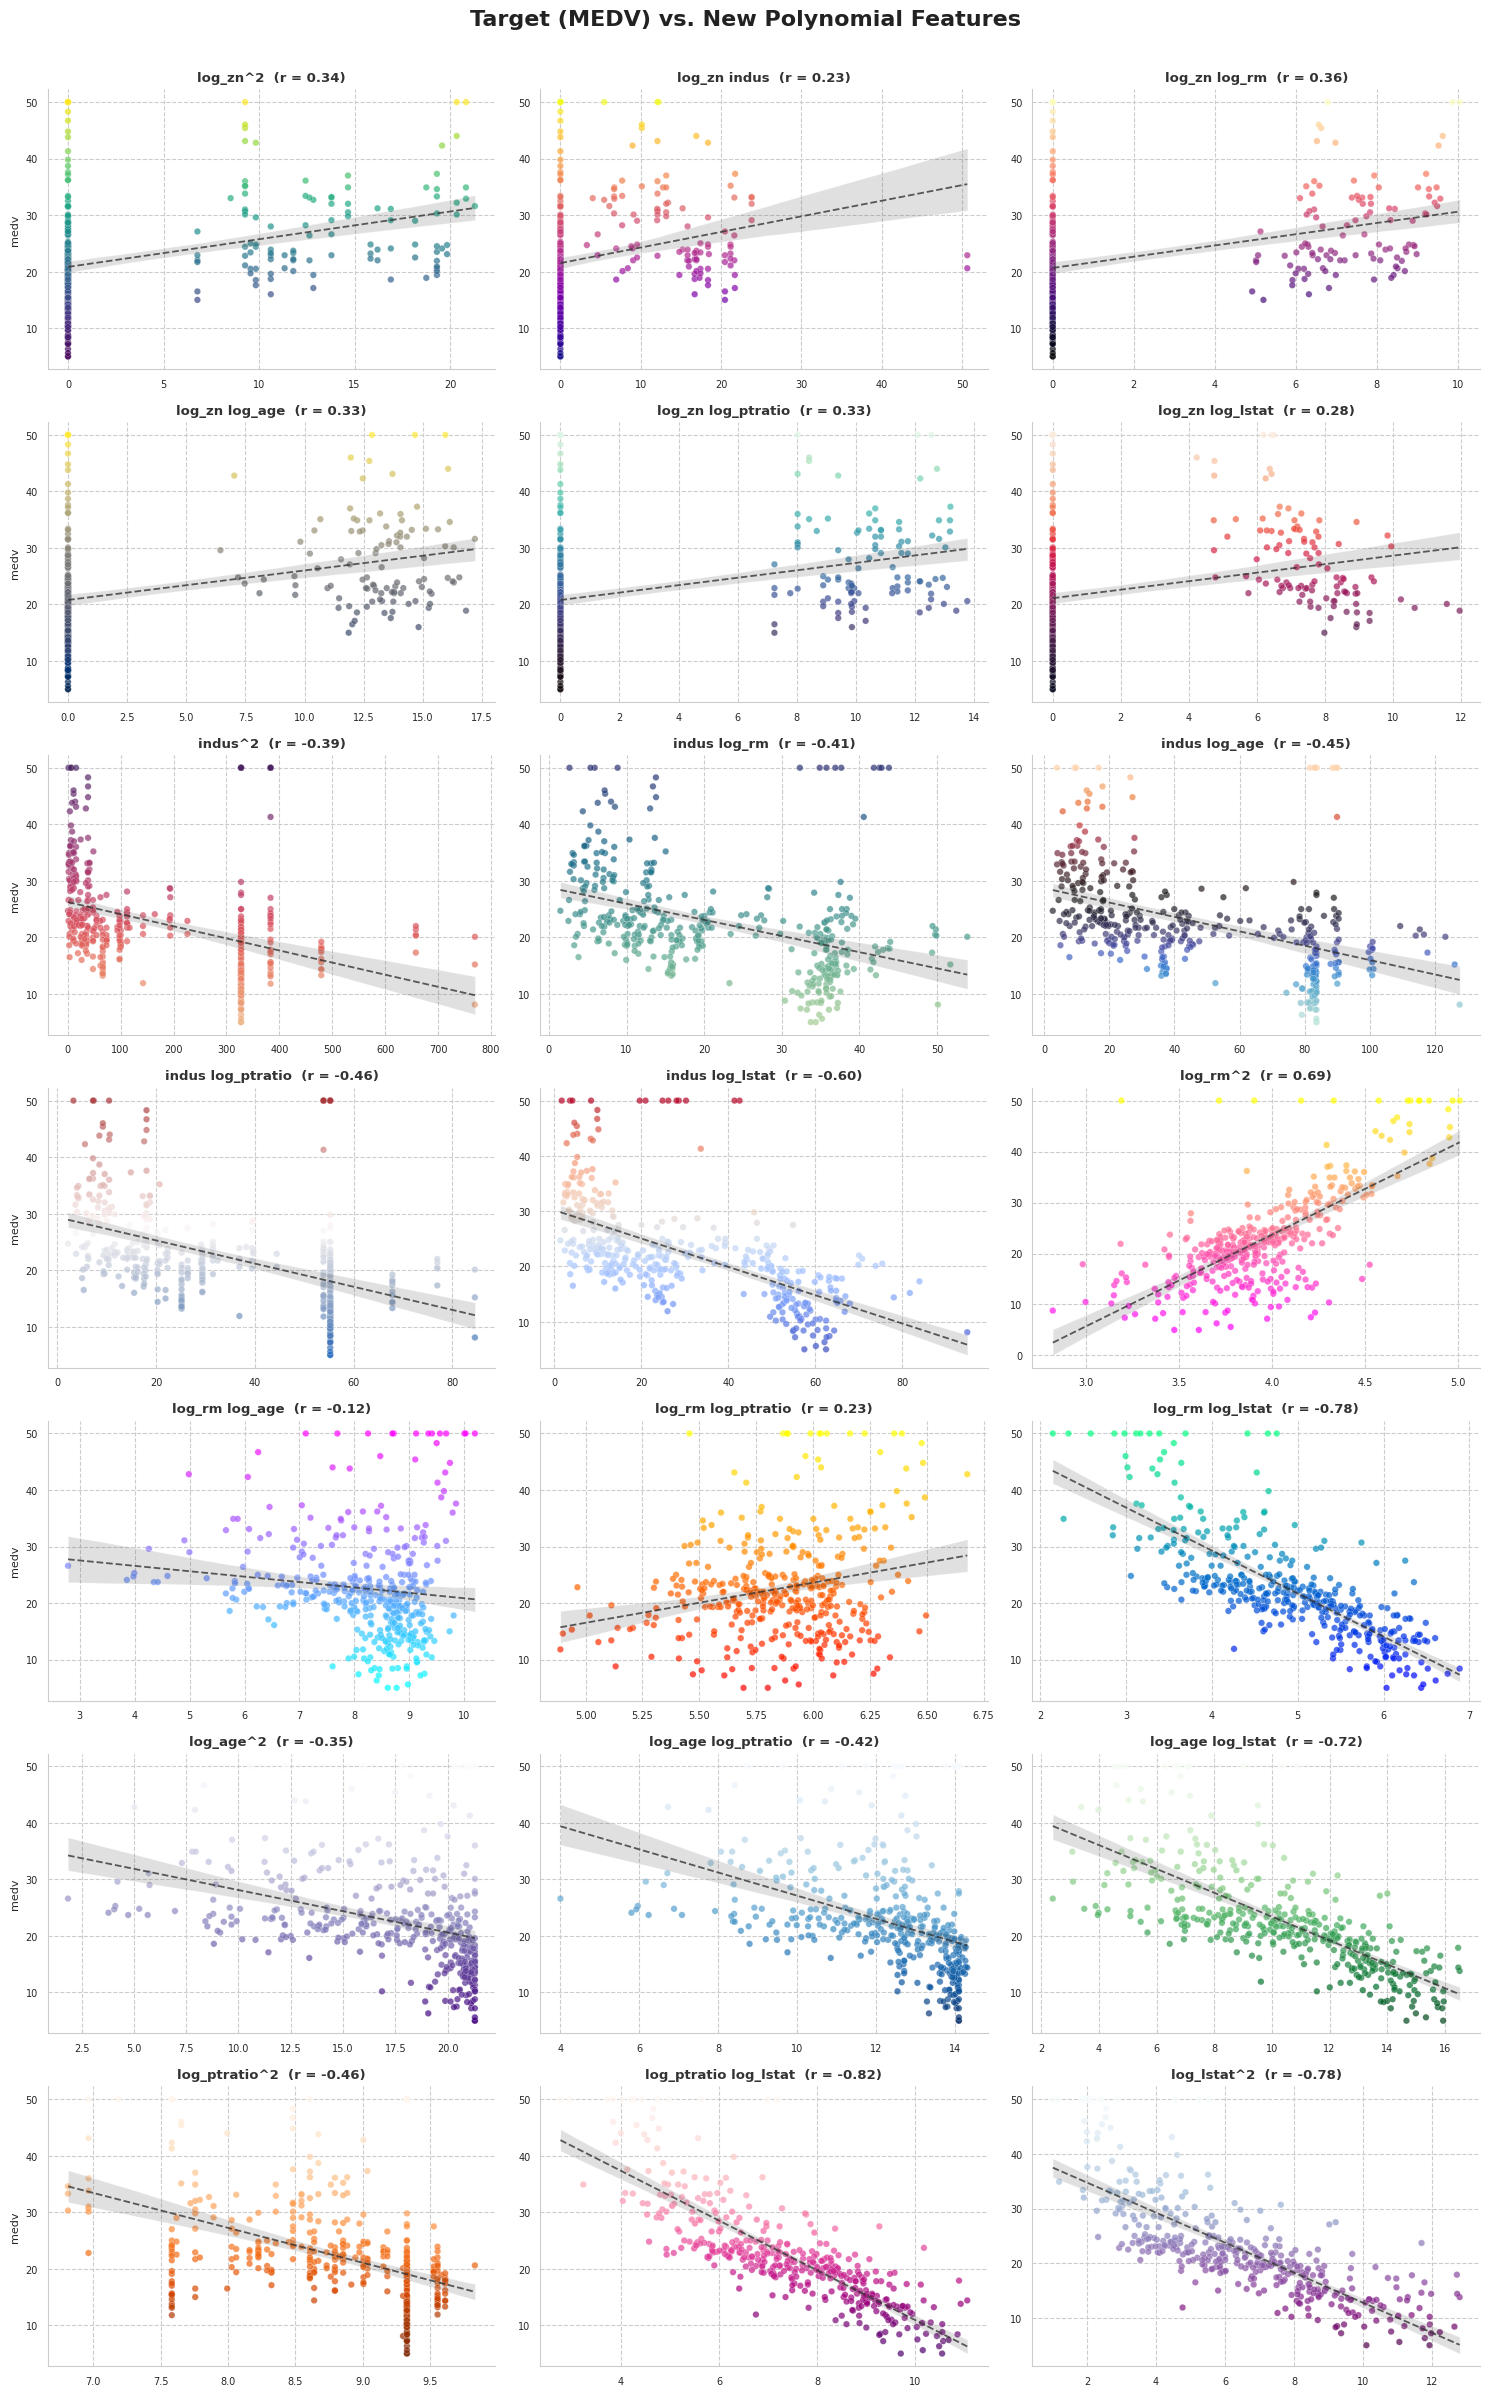

In [106]:
# Visualization 2: Scatter of target (medv) vs each new variable
cmaps = ["viridis", "plasma", "magma", "cividis", "mako", "rocket", "flare", "crest",
         "icefire", "vlag", "coolwarm", "spring", "cool", "autumn", "winter",
         "Purples_r", "Blues_r", "Greens_r", "Oranges_r", "RdPu_r", "BuPu_r"]

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.4))
axes = axes.flatten()

# Combine training data with target for easy plotting
plot_df = X_train_poly.copy()
plot_df[target] = y_train

for i, col in enumerate(new_poly_vars):
    ax = axes[i]
    r = plot_df[col].corr(plot_df[target])

    scatter = ax.scatter(
        plot_df[col], plot_df[target],
        c=plot_df[target], cmap=cmaps[i % len(cmaps)],
        alpha=0.7, s=22, edgecolor="white", linewidth=0.2
    )

    sns.regplot(x=col, y=target, data=plot_df, scatter=False, ax=ax,
                color="#333333", line_kws={"linewidth": 1.3, "linestyle": "--", "alpha": 0.8})

    ax.set_title(f"{col}  (r = {r:.2f})", fontsize=9.5, fontweight="bold", color="#333333")
    ax.set_xlabel("")
    ax.set_ylabel(target if i % ncols == 0 else "", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for j in range(len(new_poly_vars), len(axes)):
    axes[j].axis("off")

fig.suptitle("Target (MEDV) vs. New Polynomial Features",
             fontsize=16, fontweight="bold", color="#222222", y=1.005)
plt.tight_layout()
plt.show()

# Compare the regression models

The objective of this step is to compare the performance of all regression models developed in this activity and identify the model that provides the best predictive performance.

## Complete the following tasks:

1. Create a summary table using the performance results collected from each regression model.

2. Organize the table so that each row represents one regression model and each column contains a performance measure.

3. Sort the table in ascending order of RMSE so that the model with the smallest prediction error appears first.

4. Improve the readability of the table by:

- Rounding the R^2 values to four decimal places,
- Rounding the RMSE values to four decimal places, and
- Displaying the number of predictors/features as whole numbers.

5. Display the completed comparison table.

6. Identify:

- The model with the lowest RMSE, and
- The model with the highest R^2.

7. Display the names of these models.

8. Compare the models by considering:

- predictive accuracy (RMSE),
- explanatory power (R^2),
- the number of predictors/features,
- statistical significance, and
- residual diagnostics.

9.Determine whether the model with the best predictive performance also represents the most appropriate choice when model complexity and interpretability are taken into account.

### Important:

The model with the highest R^2 is not necessarily the best model. Likewise, the model with the lowest RMSE may be substantially more complex than the alternatives. When selecting a final model, consider not only predictive performance, but also simplicity, interpretability, computational cost, and the risk of overfitting. In practice, analysts often prefer the simplest model that achieves satisfactory predictive performance.



In [108]:
# Steps 1-2: Build summary table from the model_results dictionary
comparison_table = pd.DataFrame(model_results).T

# Step 3: Sort by RMSE ascending (best predictive accuracy first)
comparison_table = comparison_table.sort_values("RMSE", ascending=True)

# Step 4: Round for readability
comparison_table["R2"] = comparison_table["R2"].round(4)
comparison_table["RMSE"] = comparison_table["RMSE"].round(4)
comparison_table["n_features"] = comparison_table["n_features"].astype(int)

# Optional: rename for display purposes, to match the "Number_of_Features" label
# used in your target output, without changing the underlying dictionary key
comparison_table_display = comparison_table.rename(columns={"n_features": "Number_of_Features"})

comparison_table_display

,R2,RMSE,Number_of_Features
Polynomial Regression: Degree 2,0.8756,2.8524,27
Linear: Box-Cox Response,0.8392,3.2428,6
Linear: Log Response,0.8291,3.3441,6
Linear: Selected Log-Transformed Predictors,0.8200,3.4317,6
Linear: Original Predictors,0.7948,3.6636,6


In [109]:
# Steps 6-7: Identify best models by each metric (use the real column name)
lowest_rmse_model = comparison_table["RMSE"].idxmin()
highest_r2_model = comparison_table["R2"].idxmax()

print(f"Lowest-RMSE model: {lowest_rmse_model}")
print(f"Highest-R2 model: {highest_r2_model}")

Lowest-RMSE model: Polynomial Regression: Degree 2
Highest-R2 model: Polynomial Regression: Degree 2


# Visualize and compare model performance

The objective of this step is to create a visual comparison of the regression models so that differences in predictive performance can be identified more easily than from the summary table alone.

## Complete the following tasks:

1. Create a bar chart using the model comparison table developed in the previous step.

2. Include both of the primary performance measures:

- R^2, which measures the proportion of variation explained by the model, and
- RMSE, which measures the average prediction error.

3. Display both performance measures on the same chart using separate vertical axes so that each metric can be viewed using an appropriate scale.

4. Set an appropriate figure size so that all model names and bars can be displayed clearly.

5. Add a descriptive chart title that summarizes the purpose of the visualization.

6. Label the horizontal axis to indicate that each bar represents a different regression model.

7. Rotate the model names on the horizontal axis, if necessary, to improve readability and prevent overlapping labels.

8. Adjust the chart layout so that all labels, titles, and axes are fully visible.

9. Display the completed visualization.

10.	Use the chart to compare the regression models by identifying:

- the models with the highest R^2 values,
- the models with the lowest RMSE values,
- any models that achieve similar performance despite differing complexity, and
- whether increasing model complexity consistently improves predictive performance.

### Important:
Visualizations provide an effective way to compare competing models, but they should always be interpreted alongside the numerical performance measures and diagnostic plots. A model that appears to perform slightly better on a chart may not be preferable if the improvement is small relative to the increase in model complexity or the risk of overfitting.


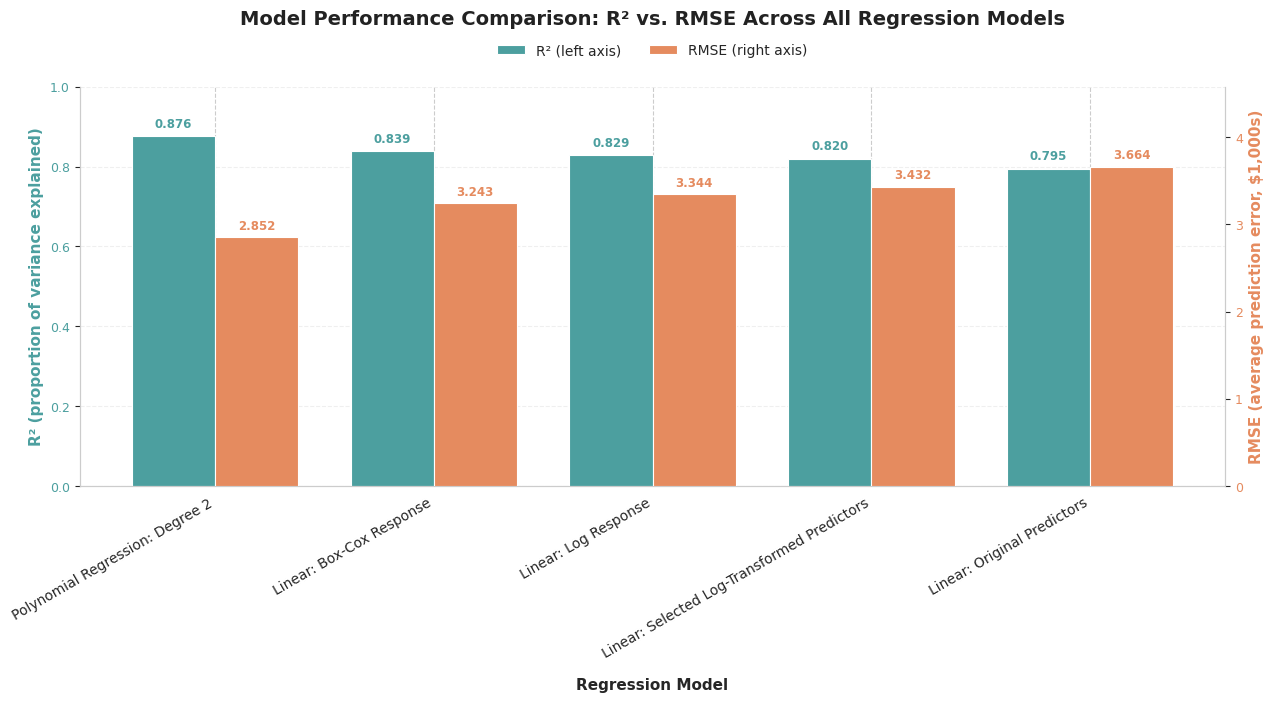

In [110]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax1 = plt.subplots(figsize=(13, 7))

models = comparison_table.index.tolist()
r2_values = comparison_table["R2"].values
rmse_values = comparison_table["RMSE"].values

x = np.arange(len(models))
bar_width = 0.38

color_r2 = "#4C9F9F"     # soft teal
color_rmse = "#E58B5F"   # warm coral

# --- R² bars (left axis) ---
bars_r2 = ax1.bar(x - bar_width/2, r2_values, width=bar_width,
                   color=color_r2, edgecolor="white", linewidth=0.8,
                   label="R² (left axis)", zorder=3)

ax1.set_ylabel("R² (proportion of variance explained)", fontsize=11, color=color_r2, fontweight="bold")
ax1.set_ylim(0, 1.0)
ax1.tick_params(axis="y", labelcolor=color_r2, labelsize=9)

# Value labels on top of R² bars
for bar, val in zip(bars_r2, r2_values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.015, f"{val:.3f}",
              ha="center", va="bottom", fontsize=8.5, color=color_r2, fontweight="bold")

# --- RMSE bars (right axis) ---
ax2 = ax1.twinx()
bars_rmse = ax2.bar(x + bar_width/2, rmse_values, width=bar_width,
                     color=color_rmse, edgecolor="white", linewidth=0.8,
                     label="RMSE (right axis)", zorder=3)

ax2.set_ylabel("RMSE (average prediction error, $1,000s)", fontsize=11, color=color_rmse, fontweight="bold")
ax2.set_ylim(0, max(rmse_values) * 1.25)
ax2.tick_params(axis="y", labelcolor=color_rmse, labelsize=9)

for bar, val in zip(bars_rmse, rmse_values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.06, f"{val:.3f}",
              ha="center", va="bottom", fontsize=8.5, color=color_rmse, fontweight="bold")

# --- Shared x-axis formatting ---
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=30, ha="right", fontsize=10)
ax1.set_xlabel("Regression Model", fontsize=11, fontweight="bold", labelpad=12)

# Gridlines behind bars only, tied to left axis for a clean single grid
ax1.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)
ax1.set_axisbelow(True)
ax2.grid(False)

# Clean spines
for spine in ["top"]:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

# Combined legend, placed clearly above the plot (not overlapping any bars)
handles = [bars_r2, bars_rmse]
labels = ["R² (left axis)", "RMSE (right axis)"]
ax1.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.14),
           ncol=2, frameon=False, fontsize=10)

plt.title("Model Performance Comparison: R² vs. RMSE Across All Regression Models",
          fontsize=14, fontweight="bold", color="#222222", pad=45)

plt.tight_layout()
plt.subplots_adjust(bottom=0.28, top=0.85)
plt.show()

**Highest R^2 / Lowest RMSE:** Polynomial Regression: Degree 2 leads on both metrics simultaneously, visually the tallest teal bar and shortest coral bar.

**Similar performance despite differing complexity:** Box-Cox Response and Log Response show nearly identical bar heights on both axes (R^2 ≈ 0.83-0.84, RMSE ≈ 3.2-3.3), visually almost indistinguishable from each other, despite both being simpler (6 features) than the polynomial model. This is a good visual cue that these two transformation choices are functionally interchangeable in performance.

**Does complexity consistently improve performance?** The chart shows a generally improving trend from right (Original Predictors) to left (Polynomial), but the *size* of each step matters: the jump from Original Predictors to the three transformed-response/predictor models (6 features each) is visually substantial, while the further jump to the Polynomial model (27 features) is comparatively smaller relative to how much complexity was added,  visually, the bar height gain from Log Response to Polynomial is modest, even though the feature count more than quadrupled. This reinforces the point from the previous step: complexity and performance don't scale proportionally here, which is exactly the kind of pattern a chart like this is meant to make visually obvious rather than just stated in a table.

# Compare model predictions for a single test case

The objective of this final step is to examine how the regression models predict the response value for the same individual observation.

## Complete the following tasks:

1. Select one observation from the testing predictor dataset to use as a sample case.

2. Preserve the selected observation as a one-row predictor dataset so that it remains compatible with the prediction methods used by the regression models.

3. Retrieve the actual MEDV value associated with the selected test observation.

4. Generate a prediction from the baseline linear regression model.

- Use the original versions of the selected predictors.
- Ensure that the predictors are presented in the same order used when the baseline model was trained.

5. Generate a prediction from the linear regression model that uses the selected log-transformed predictors.

6. Generate a prediction from the Box-Cox response model.

- First obtain the prediction on the Box-Cox-transformed scale.
- Then apply the inverse Box-Cox transformation to return the prediction to the original MEDV scale.

7. Generate a prediction from the log-response model.

- First obtain the prediction on the logarithmic response scale.
- Then apply the appropriate inverse transformation to return the prediction to the original MEDV scale.

8. Generate a prediction from the polynomial regression model.

- Apply the previously fitted polynomial transformer to the sample case.
- Use the resulting polynomial features as input to the polynomial regression model.

9. Store the following values in a clearly labelled structure:

- the actual MEDV value,
- the baseline model prediction,
- the log-predictor model prediction,
- the Box-Cox response model prediction,
- the log-response model prediction, and
- the polynomial regression model prediction.

10.	Convert the stored values into a labelled one-dimensional summary and display the results.

11.	Compare the predictions and determine:

- which model produced the prediction closest to the actual value,
- which model produced the largest prediction error,
- whether the more complex models consistently performed better for this observation, and
- whether the model ranked best by overall RMSE also performed best for this particular case.

### Important:
A single observation can help illustrate how model predictions differ, but it is not sufficient for selecting the best model. Final model selection should be based primarily on overall testing performance, residual diagnostics, statistical significance, complexity, and interpretability.



,MEDV Prediction
Actual MEDV,23.100000
Linear: Original Predictors,15.633744
Linear: Selected Log-Transformed Predictors,14.117206
Linear: Box-Cox Response,15.080153
Linear: Log Response,15.194630
Polynomial Regression: Degree 2,19.326186
